## Work Trial - Stefan Heimersheim

**Please do not share information about this worktrial publicly or with other candidates.**

### Instructions
- [ ] Save a copy of this colab notebook to your own drive  (File > Save a copy in Drive) and update the sharing settings to “anyone with the link can edit."
- [ ] Create a separate Google Doc to write up your results and notes. Stefan will mainly judge your writeup in the Doc, focus on that one over the Colab.
  - [ ] Give Stefan (stefan.heimersheim@gmail.com) *edit* access to the Google Doc
  - [ ] At the top of the doc include a line "Name: [your name] Email: [your email]"
  - [ ] Add a link to the Colab at the top of the doc.
- [ ] Set a timer and start investigating. Please do not spend more than 2 hours on this task, and spend ~30 minutes on producing a good writeup.



This notebook explores **two** small experiments related to computation in superposition.

The first task is likely shorter than the second. Don't spend more than 45 minutes on the first task, and expect to spend 30 minutes producing a write-up / summary doc. (Again no need for high level of polish, just screenshot plots from the notebook.)

First, train a tiny one-layer transformer-like model on an overcomplete memorization task. The model sees a key and must predict a randomly assigned value.

Second, test memorization in GPT-2. Load a small dataset facts (provided), evaluate which facts GPT-2 knows, and test where in the model the answer is represented.

Most of the code below is LLM-written but I have mostly checked it.

**Important: Go to Runtime > Change Runtime Type to select a GPU (T4) runtime, otherwise the GPT-2 code in the 2nd task will be slow!**

### Setup code (run this while reading)

In [ ]:
!pip install transformer_lens

In [ ]:
from __future__ import annotations

import argparse
import dataclasses
import json
import math
import random
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange
from tqdm.auto import trange
from tqdm.auto import tqdm
from transformer_lens import HookedTransformer
from transformer_lens.utils import test_prompt

/tmp/ipykernel_27523/2262092155.py:21: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens.utils import test_prompt


In [ ]:
def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

In [ ]:
# Download this model for task 2, so it's cached on disk
model_name = "gpt2-small"
_ = HookedTransformer.from_pretrained(
    model_name,
    device="cpu",
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
)
del _

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer


## Task 1: Toy memorization experiment

A Tiny One-Layer Transformer Memorization Task. The model sees `[BOS, key_token]` and must predict a randomly assigned
`value_token`.

Questions to answer:

1. Can the model memorize many more key-value pairs than it has MLP neurons?
2. Why is this not, by itself, a good toy model of computation in superposition?
3. What would need to change to make the toy model actually test computation in superposition?

In [ ]:
class TinyOneLayerTransformer(nn.Module):
    """Small enough to understand, close enough to a real transformer block."""

    def __init__(self, n_keys: int, n_values: int, d_model: int, d_mlp: int, n_heads: int):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_keys = n_keys
        self.n_values = n_values
        self.d_model = d_model
        self.d_mlp = d_mlp
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.bos_id = n_keys

        self.token_embed = nn.Embedding(n_keys + 1, d_model)
        self.pos_embed = nn.Parameter(torch.randn(2, d_model) / math.sqrt(d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.attn_out = nn.Linear(d_model, d_model, bias=False)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp_in = nn.Linear(d_model, d_mlp)
        self.mlp_out = nn.Linear(d_mlp, d_model)
        self.unembed = nn.Linear(d_model, n_values, bias=False)

    def forward(self, tokens: torch.Tensor, return_cache: bool = False):
        batch, seq = tokens.shape
        assert seq == 2
        x = self.token_embed(tokens) + self.pos_embed[None, :, :]

        resid_pre = x
        h = self.ln1(x)
        qkv = self.qkv(h)
        q, k, v = qkv.chunk(3, dim=-1)
        q = rearrange(q, "b s (h d) -> b h s d", h=self.n_heads)
        k = rearrange(k, "b s (h d) -> b h s d", h=self.n_heads)
        v = rearrange(v, "b s (h d) -> b h s d", h=self.n_heads)
        attn_scores = torch.einsum("b h q d, b h k d -> b h q k", q, k) / math.sqrt(self.d_head)
        causal_mask = torch.tril(torch.ones(seq, seq, device=tokens.device, dtype=torch.bool))
        attn_scores = attn_scores.masked_fill(~causal_mask, -1e9)
        attn = attn_scores.softmax(dim=-1)
        z = torch.einsum("b h q k, b h k d -> b h q d", attn, v)
        z = rearrange(z, "b h s d -> b s (h d)")
        resid_mid = resid_pre + self.attn_out(z)

        mlp_pre = self.mlp_in(self.ln2(resid_mid))
        mlp_act = F.gelu(mlp_pre)
        resid_post = resid_mid + self.mlp_out(mlp_act)
        logits = self.unembed(resid_post[:, -1, :])

        if not return_cache:
            return logits
        cache = {
            "resid_pre": resid_pre.detach(),
            "resid_mid": resid_mid.detach(),
            "mlp_pre": mlp_pre.detach(),
            "mlp_act": mlp_act.detach(),
            "resid_post": resid_post.detach(),
            "attn": attn.detach(),
        }
        return logits, cache


def make_random_mapping(n_pairs: int, seed: int) -> torch.Tensor:
    generator = torch.Generator().manual_seed(seed)
    return torch.randperm(n_pairs, generator=generator)


def sample_batch(mapping: torch.Tensor, batch_size: int, bos_id: int, device: torch.device):
    idx = torch.randint(0, len(mapping), (batch_size,), device=device)
    x = torch.stack([torch.full_like(idx, bos_id), idx], dim=1)
    y = mapping.to(device)[idx]
    return x, y


def train_toy_model(cfg: ToyConfig, device: torch.device):
    set_seed(cfg.seed)
    mapping = make_random_mapping(cfg.n_pairs, cfg.seed)
    model = TinyOneLayerTransformer(
        n_keys=cfg.n_pairs,
        n_values=cfg.n_pairs,
        d_model=cfg.d_model,
        d_mlp=cfg.d_mlp,
        n_heads=cfg.n_heads,
    ).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=0.01)

    pbar = trange(cfg.steps, desc="training toy model")
    for step in pbar:
        x, y = sample_batch(mapping, cfg.batch_size, model.bos_id, device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if step % 25 == 0 or step == cfg.steps - 1:
            with torch.no_grad():
                acc = (logits.argmax(dim=-1) == y).float().mean().item()
            pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{acc:.3f}")

    return model, mapping


@torch.no_grad()
def evaluate_toy_model(model: TinyOneLayerTransformer, mapping: torch.Tensor, device: torch.device, batch_size: int = 512):
    correct = 0
    total = 0
    losses = []
    for start in range(0, len(mapping), batch_size):
        keys = torch.arange(start, min(start + batch_size, len(mapping)), device=device)
        x = torch.stack([torch.full_like(keys, model.bos_id), keys], dim=1)
        y = mapping.to(device)[keys]
        logits = model(x)
        losses.append(F.cross_entropy(logits, y, reduction="sum").item())
        correct += int((logits.argmax(dim=-1) == y).sum().item())
        total += len(keys)
    return {"loss": sum(losses) / total, "accuracy": correct / total}

  0%|          | 0/1000 [00:00<?, ?it/s]

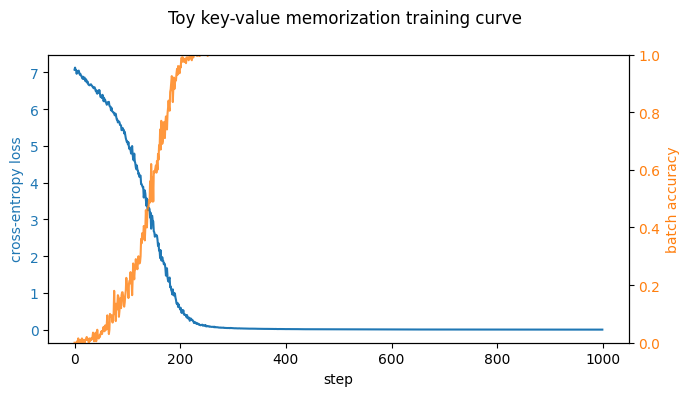

In [ ]:
@dataclasses.dataclass
class ToyConfig:
    n_pairs: int = 1024
    d_model: int = 32
    d_mlp: int = 128
    n_heads: int = 4
    batch_size: int = 200
    steps: int = 1000
    lr: float = 1e-3
    seed: int = 0

cfg = ToyConfig()

device = get_device()
set_seed(cfg.seed)
mapping = make_random_mapping(cfg.n_pairs, cfg.seed)

model = TinyOneLayerTransformer(
    n_keys=cfg.n_pairs,
    n_values=cfg.n_pairs,
    d_model=cfg.d_model,
    d_mlp=cfg.d_mlp,
    n_heads=cfg.n_heads,
).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=0.01)

history = []

for step in trange(cfg.steps):
    x, y = sample_batch(mapping, cfg.batch_size, model.bos_id, device)
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    with torch.no_grad():
        acc = (logits.argmax(dim=-1) == y).float().mean().item()

    history.append({
        "step": step,
        "loss": loss.item(),
        "batch_accuracy": acc,
    })

history_df = pd.DataFrame(history)

fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(history_df["step"], history_df["loss"], label="loss", color="tab:blue")
ax1.set_xlabel("step")
ax1.set_ylabel("cross-entropy loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(
    history_df["step"],
    history_df["batch_accuracy"],
    label="batch accuracy",
    color="tab:orange",
    alpha=0.8,
)
ax2.set_ylabel("batch accuracy", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(0, 1)

fig.suptitle("Toy key-value memorization training curve")
fig.tight_layout()
plt.show()

## Task 2: GPT-2 memorized facts experiment

This task is intentionally exploratory. The goal is not to prove where facts are stored in GPT-2, but to get a rough empirical picture and identify limitations.

The notebook provides a dataset of factual prompts and helper code that computes GPT-2's accuracy on them.

Questions & goals:
1. Run the provided fact-evaluation code on GPT-2 Small and make 1-2 plots showing GPT-2's performance. Pick a suitable subset of the data.
2. Use LogitLens on the residual stream across layers to analyze where in the model the answer tends to emerge. Is it smooth or localized? Don't attempt a full circuit-level understanding.
3. What are potential issues and confounders with this experiment and data? How would you improve that?
4. [If you have time left] What would be better ways to measure this? Consider e.g. activation patching or probing.


#### Giant list of facts (collapsed for readability)



In [ ]:

FACTS = [
    ('capital', 'Paris is the capital city of', ' France'),
    ('capital', 'Berlin is the capital city of', ' Germany'),
    ('capital', 'Rome is the capital city of', ' Italy'),
    ('capital', 'Madrid is the capital city of', ' Spain'),
    ('capital', 'Lisbon is the capital city of', ' Portugal'),
    ('capital', 'Dublin is the capital city of', ' Ireland'),
    ('capital', 'London is the capital city of', ' the United Kingdom'),
    ('capital', 'Brussels is the capital city of', ' Belgium'),
    ('capital', 'Amsterdam is the capital city of', ' the Netherlands'),
    ('capital', 'Luxembourg is the capital city of', ' Luxembourg'),
    ('capital', 'Bern is the capital city of', ' Switzerland'),
    ('capital', 'Vienna is the capital city of', ' Austria'),
    ('capital', 'Prague is the capital city of', ' the Czech Republic'),
    ('capital', 'Warsaw is the capital city of', ' Poland'),
    ('capital', 'Bratislava is the capital city of', ' Slovakia'),
    ('capital', 'Budapest is the capital city of', ' Hungary'),
    ('capital', 'Ljubljana is the capital city of', ' Slovenia'),
    ('capital', 'Zagreb is the capital city of', ' Croatia'),
    ('capital', 'Sarajevo is the capital city of', ' Bosnia and Herzegovina'),
    ('capital', 'Belgrade is the capital city of', ' Serbia'),
    ('capital', 'Podgorica is the capital city of', ' Montenegro'),
    ('capital', 'Skopje is the capital city of', ' North Macedonia'),
    ('capital', 'Tirana is the capital city of', ' Albania'),
    ('capital', 'Athens is the capital city of', ' Greece'),
    ('capital', 'Sofia is the capital city of', ' Bulgaria'),
    ('capital', 'Bucharest is the capital city of', ' Romania'),
    ('capital', 'Chisinau is the capital city of', ' Moldova'),
    ('capital', 'Kyiv is the capital city of', ' Ukraine'),
    ('capital', 'Minsk is the capital city of', ' Belarus'),
    ('capital', 'Vilnius is the capital city of', ' Lithuania'),
    ('capital', 'Riga is the capital city of', ' Latvia'),
    ('capital', 'Tallinn is the capital city of', ' Estonia'),
    ('capital', 'Helsinki is the capital city of', ' Finland'),
    ('capital', 'Stockholm is the capital city of', ' Sweden'),
    ('capital', 'Oslo is the capital city of', ' Norway'),
    ('capital', 'Copenhagen is the capital city of', ' Denmark'),
    ('capital', 'Reykjavik is the capital city of', ' Iceland'),
    ('capital', 'Valletta is the capital city of', ' Malta'),
    ('capital', 'Nicosia is the capital city of', ' Cyprus'),
    ('capital', 'Tokyo is the capital city of', ' Japan'),
    ('capital', 'Seoul is the capital city of', ' South Korea'),
    ('capital', 'Beijing is the capital city of', ' China'),
    ('capital', 'Ulaanbaatar is the capital city of', ' Mongolia'),
    ('capital', 'Pyongyang is the capital city of', ' North Korea'),
    ('capital', 'New Delhi is the capital city of', ' India'),
    ('capital', 'Islamabad is the capital city of', ' Pakistan'),
    ('capital', 'Kathmandu is the capital city of', ' Nepal'),
    ('capital', 'Thimphu is the capital city of', ' Bhutan'),
    ('capital', 'Dhaka is the capital city of', ' Bangladesh'),
    ('capital', 'Colombo is the capital city of', ' Sri Lanka'),
    ('capital', 'Malé is the capital city of', ' the Maldives'),
    ('capital', 'Bangkok is the capital city of', ' Thailand'),
    ('capital', 'Hanoi is the capital city of', ' Vietnam'),
    ('capital', 'Vientiane is the capital city of', ' Laos'),
    ('capital', 'Phnom Penh is the capital city of', ' Cambodia'),
    ('capital', 'Naypyidaw is the capital city of', ' Myanmar'),
    ('capital', 'Kuala Lumpur is the capital city of', ' Malaysia'),
    ('capital', 'Singapore is the capital city of', ' Singapore'),
    ('capital', 'Jakarta is the capital city of', ' Indonesia'),
    ('capital', 'Manila is the capital city of', ' the Philippines'),
    ('capital', 'Bandar Seri Begawan is the capital city of', ' Brunei'),
    ('capital', 'Dili is the capital city of', ' Timor-Leste'),
    ('capital', 'Ankara is the capital city of', ' Turkey'),
    ('capital', 'Tbilisi is the capital city of', ' Georgia'),
    ('capital', 'Yerevan is the capital city of', ' Armenia'),
    ('capital', 'Baku is the capital city of', ' Azerbaijan'),
    ('capital', 'Tehran is the capital city of', ' Iran'),
    ('capital', 'Baghdad is the capital city of', ' Iraq'),
    ('capital', 'Riyadh is the capital city of', ' Saudi Arabia'),
    ('capital', 'Doha is the capital city of', ' Qatar'),
    ('capital', 'Manama is the capital city of', ' Bahrain'),
    ('capital', 'Kuwait City is the capital city of', ' Kuwait'),
    ('capital', 'Muscat is the capital city of', ' Oman'),
    ('capital', 'Abu Dhabi is the capital city of', ' the United Arab Emirates'),
    ('capital', "Sana'a is the capital city of", ' Yemen'),
    ('capital', 'Amman is the capital city of', ' Jordan'),
    ('capital', 'Beirut is the capital city of', ' Lebanon'),
    ('capital', 'Damascus is the capital city of', ' Syria'),
    ('capital', 'Kabul is the capital city of', ' Afghanistan'),
    ('capital', 'Astana is the capital city of', ' Kazakhstan'),
    ('capital', 'Tashkent is the capital city of', ' Uzbekistan'),
    ('capital', 'Bishkek is the capital city of', ' Kyrgyzstan'),
    ('capital', 'Dushanbe is the capital city of', ' Tajikistan'),
    ('capital', 'Ashgabat is the capital city of', ' Turkmenistan'),
    ('capital', 'Cairo is the capital city of', ' Egypt'),
    ('capital', 'Rabat is the capital city of', ' Morocco'),
    ('capital', 'Algiers is the capital city of', ' Algeria'),
    ('capital', 'Tunis is the capital city of', ' Tunisia'),
    ('capital', 'Tripoli is the capital city of', ' Libya'),
    ('capital', 'Khartoum is the capital city of', ' Sudan'),
    ('capital', 'Juba is the capital city of', ' South Sudan'),
    ('capital', 'Addis Ababa is the capital city of', ' Ethiopia'),
    ('capital', 'Asmara is the capital city of', ' Eritrea'),
    ('capital', 'Djibouti is the capital city of', ' Djibouti'),
    ('capital', 'Mogadishu is the capital city of', ' Somalia'),
    ('capital', 'Nairobi is the capital city of', ' Kenya'),
    ('capital', 'Kampala is the capital city of', ' Uganda'),
    ('capital', 'Kigali is the capital city of', ' Rwanda'),
    ('capital', 'Gitega is the capital city of', ' Burundi'),
    ('capital', 'Dodoma is the capital city of', ' Tanzania'),
    ('capital', 'Lusaka is the capital city of', ' Zambia'),
    ('capital', 'Harare is the capital city of', ' Zimbabwe'),
    ('capital', 'Maputo is the capital city of', ' Mozambique'),
    ('capital', 'Pretoria is the capital city of', ' South Africa'),
    ('capital', 'Gaborone is the capital city of', ' Botswana'),
    ('capital', 'Windhoek is the capital city of', ' Namibia'),
    ('capital', 'Luanda is the capital city of', ' Angola'),
    ('capital', 'Kinshasa is the capital city of', ' the Democratic Republic of the Congo'),
    ('capital', 'Brazzaville is the capital city of', ' the Republic of the Congo'),
    ('capital', 'Libreville is the capital city of', ' Gabon'),
    ('capital', 'Yaoundé is the capital city of', ' Cameroon'),
    ('capital', 'Abuja is the capital city of', ' Nigeria'),
    ('capital', 'Accra is the capital city of', ' Ghana'),
    ('capital', 'Dakar is the capital city of', ' Senegal'),
    ('capital', 'Washington, D.C. is the capital city of', ' the United States'),
    ('capital', 'Ottawa is the capital city of', ' Canada'),
    ('capital', 'Mexico City is the capital city of', ' Mexico'),
    ('capital', 'Guatemala City is the capital city of', ' Guatemala'),
    ('capital', 'Belmopan is the capital city of', ' Belize'),
    ('capital', 'San Salvador is the capital city of', ' El Salvador'),
    ('capital', 'Tegucigalpa is the capital city of', ' Honduras'),
    ('capital', 'Managua is the capital city of', ' Nicaragua'),
    ('capital', 'San José is the capital city of', ' Costa Rica'),
    ('capital', 'Panama City is the capital city of', ' Panama'),
    ('capital', 'Havana is the capital city of', ' Cuba'),
    ('capital', 'Kingston is the capital city of', ' Jamaica'),
    ('capital', 'Port-au-Prince is the capital city of', ' Haiti'),
    ('capital', 'Santo Domingo is the capital city of', ' the Dominican Republic'),
    ('landmark', 'The Eiffel Tower is located in', ' Paris'),
    ('landmark', 'The Louvre is located in', ' Paris'),
    ('landmark', 'Notre-Dame Cathedral is located in', ' Paris'),
    ('landmark', 'The Arc de Triomphe is located in', ' Paris'),
    ('landmark', 'The Palace of Versailles is located in', ' France'),
    ('landmark', 'Mont Saint-Michel is located in', ' France'),
    ('landmark', 'The Colosseum is located in', ' Rome'),
    ('landmark', 'The Pantheon is located in', ' Rome'),
    ('landmark', 'The Leaning Tower of Pisa is located in', ' Pisa'),
    ('landmark', 'Pompeii is located in', ' Italy'),
    ('landmark', 'The Grand Canal is located in', ' Venice'),
    ('landmark', 'The Sagrada Família is located in', ' Barcelona'),
    ('landmark', 'The Alhambra is located in', ' Granada'),
    ('landmark', 'Park Güell is located in', ' Barcelona'),
    ('landmark', 'The Prado Museum is located in', ' Madrid'),
    ('landmark', 'Stonehenge is located in', ' England'),
    ('landmark', 'The Tower of London is located in', ' London'),
    ('landmark', 'Big Ben is located in', ' London'),
    ('landmark', 'Buckingham Palace is located in', ' London'),
    ('landmark', 'Edinburgh Castle is located in', ' Scotland'),
    ('landmark', 'The Acropolis is located in', ' Athens'),
    ('landmark', 'The Parthenon is located in', ' Athens'),
    ('landmark', 'Meteora is located in', ' Greece'),
    ('landmark', 'The Brandenburg Gate is located in', ' Berlin'),
    ('landmark', 'Neuschwanstein Castle is located in', ' Germany'),
    ('landmark', 'Cologne Cathedral is located in', ' Germany'),
    ('landmark', 'Schönbrunn Palace is located in', ' Vienna'),
    ('landmark', 'Belém Tower is located in', ' Lisbon'),
    ('landmark', 'Jerónimos Monastery is located in', ' Lisbon'),
    ('landmark', 'Charles Bridge is located in', ' Prague'),
    ('landmark', 'Prague Castle is located in', ' Prague'),
    ('landmark', 'Wawel Castle is located in', ' Kraków'),
    ('landmark', 'Auschwitz-Birkenau is located in', ' Poland'),
    ('landmark', "Fisherman's Bastion is located in", ' Budapest'),
    ('landmark', 'Buda Castle is located in', ' Budapest'),
    ('landmark', 'The Rijksmuseum is located in', ' Amsterdam'),
    ('landmark', 'The Anne Frank House is located in', ' Amsterdam'),
    ('landmark', 'The Atomium is located in', ' Brussels'),
    ('landmark', 'The Grand Place is located in', ' Brussels'),
    ('landmark', 'The Matterhorn is located in', ' Switzerland'),
    ('landmark', 'The Kremlin is located in', ' Moscow'),
    ('landmark', 'Red Square is located in', ' Moscow'),
    ('landmark', "Saint Basil's Cathedral is located in", ' Moscow'),
    ('landmark', 'The Hermitage Museum is located in', ' Saint Petersburg'),
    ('landmark', 'Hagia Sophia is located in', ' Istanbul'),
    ('landmark', 'The Blue Mosque is located in', ' Istanbul'),
    ('landmark', 'Topkapı Palace is located in', ' Istanbul'),
    ('landmark', 'Petra is located in', ' Jordan'),
    ('landmark', 'The Burj Khalifa is located in', ' Dubai'),
    ('landmark', 'Sheikh Zayed Grand Mosque is located in', ' Abu Dhabi'),
    ('landmark', 'The Taj Mahal is located in', ' India'),
    ('landmark', 'The Red Fort is located in', ' Delhi'),
    ('landmark', 'Qutub Minar is located in', ' Delhi'),
    ('landmark', 'The Golden Temple is located in', ' Amritsar'),
    ('landmark', 'The Great Wall is located in', ' China'),
    ('landmark', 'The Forbidden City is located in', ' Beijing'),
    ('landmark', 'The Terracotta Army is located in', " Xi'an"),
    ('landmark', 'The Summer Palace is located in', ' Beijing'),
    ('landmark', 'The Potala Palace is located in', ' Lhasa'),
    ('landmark', 'Mount Fuji is located in', ' Japan'),
    ('landmark', 'Kinkaku-ji is located in', ' Kyoto'),
    ('landmark', 'Fushimi Inari Shrine is located in', ' Kyoto'),
    ('landmark', 'Angkor Wat is located in', ' Cambodia'),
    ('landmark', 'Borobudur is located in', ' Indonesia'),
    ('landmark', 'Prambanan is located in', ' Indonesia'),
    ('landmark', 'Shwedagon Pagoda is located in', ' Yangon'),
    ('landmark', 'The Grand Palace is located in', ' Bangkok'),
    ('landmark', 'Wat Arun is located in', ' Bangkok'),
    ('landmark', 'The Petronas Towers are located in', ' Kuala Lumpur'),
    ('landmark', 'Marina Bay Sands is located in', ' Singapore'),
    ('landmark', 'The Merlion is located in', ' Singapore'),
    ('landmark', 'Gyeongbokgung Palace is located in', ' Seoul'),
    ('landmark', 'Taipei 101 is located in', ' Taipei'),
    ('landmark', 'The Chocolate Hills are located in', ' the Philippines'),
    ('landmark', 'The Banaue Rice Terraces are located in', ' the Philippines'),
    ('landmark', 'Ha Long Bay is located in', ' Vietnam'),
    ('landmark', 'Mỹ Sơn is located in', ' Vietnam'),
    ('landmark', 'The Pyramids of Giza are located in', ' Egypt'),
    ('landmark', 'The Great Sphinx is located in', ' Giza'),
    ('landmark', 'Abu Simbel is located in', ' Egypt'),
    ('landmark', 'Karnak Temple is located in', ' Luxor'),
    ('landmark', 'The Valley of the Kings is located in', ' Egypt'),
    ('landmark', 'Hassan II Mosque is located in', ' Casablanca'),
    ('landmark', 'Jemaa el-Fnaa is located in', ' Marrakesh'),
    ('landmark', 'Carthage is located in', ' Tunisia'),
    ('landmark', 'Table Mountain is located in', ' Cape Town'),
    ('landmark', 'Robben Island is located in', ' South Africa'),
    ('landmark', 'Victoria Falls is located in', ' Africa'),
    ('landmark', 'Mount Kilimanjaro is located in', ' Tanzania'),
    ('landmark', 'Serengeti National Park is located in', ' Tanzania'),
    ('landmark', 'The Maasai Mara is located in', ' Kenya'),
    ('landmark', 'The rock-hewn churches of Lalibela are located in', ' Ethiopia'),
    ('landmark', 'Great Zimbabwe is located in', ' Zimbabwe'),
    ('landmark', 'Timbuktu is located in', ' Mali'),
    ('landmark', 'The Great Mosque of Djenné is located in', ' Mali'),
    ('landmark', 'Gorée Island is located in', ' Senegal'),
    ('landmark', 'Cape Coast Castle is located in', ' Ghana'),
    ('landmark', 'The Statue of Liberty is located in New', ' York'),
    ('landmark', 'The Empire State Building is located in New', ' York'),
    ('landmark', 'The Golden Gate Bridge is located in', ' San Francisco'),
    ('landmark', 'The Grand Canyon is located in', ' Arizona'),
    ('landmark', 'Mount Rushmore is located in South', ' Dakota'),
    ('landmark', 'Yellowstone National Park is located primarily in', ' Wyoming'),
    ('landmark', 'Yosemite Valley is located in', ' California'),
    ('landmark', 'The Hollywood Sign is located in Los', ' Angeles'),
    ('landmark', 'The White House is located in Washington,', ' D.C.'),
    ('landmark', 'The CN Tower is located in', ' Toronto'),
    ('landmark', 'Niagara Falls is located on the border of Canada and the United', ' States'),
    ('landmark', 'Chichen Itza is located in', ' Mexico'),
    ('landmark', 'Teotihuacan is located in', ' Mexico'),
    ('landmark', 'Tulum is located in', ' Mexico'),
    ('landmark', 'Machu Picchu is located in', ' Peru'),
    ('landmark', 'The Nazca Lines are located in', ' Peru'),
    ('landmark', 'Christ the Redeemer is located in Rio de', ' Janeiro'),
    ('landmark', 'Sugarloaf Mountain is located in Rio de', ' Janeiro'),
    ('landmark', 'Iguazu Falls is located on the border of Brazil and', ' Argentina'),
    ('landmark', 'Perito Moreno Glacier is located in', ' Argentina'),
    ('landmark', 'Easter Island is part of', ' Chile'),
    ('landmark', 'The moai statues are located on Easter', ' Island'),
    ('landmark', 'The Atacama Desert is located in', ' Chile'),
    ('landmark', 'The Galápagos Islands are part of', ' Ecuador'),
    ('landmark', 'The Sydney Opera House is located in', ' Sydney'),
    ('landmark', 'The Sydney Harbour Bridge is located in', ' Sydney'),
    ('landmark', 'Uluru is located in', ' Australia'),
    ('landmark', 'The Great Barrier Reef is located in', ' Australia'),
    ('landmark', 'The Sky Tower is located in', ' Auckland'),
    ('landmark', 'Hobbiton is located in', ' New Zealand'),
    ('landmark', 'Milford Sound is located in', ' New Zealand'),
    ('geography', 'France is a country in', ' Europe'),
    ('geography', 'Germany is a country in', ' Europe'),
    ('geography', 'Italy is a country in', ' Europe'),
    ('geography', 'Spain is a country in', ' Europe'),
    ('geography', 'Portugal is a country in', ' Europe'),
    ('geography', 'Ireland is a country in', ' Europe'),
    ('geography', 'The United Kingdom is a country in', ' Europe'),
    ('geography', 'Belgium is a country in', ' Europe'),
    ('geography', 'The Netherlands is a country in', ' Europe'),
    ('geography', 'Luxembourg is a country in', ' Europe'),
    ('geography', 'Switzerland is a country in', ' Europe'),
    ('geography', 'Austria is a country in', ' Europe'),
    ('geography', 'The Czech Republic is a country in', ' Europe'),
    ('geography', 'Poland is a country in', ' Europe'),
    ('geography', 'Slovakia is a country in', ' Europe'),
    ('geography', 'Hungary is a country in', ' Europe'),
    ('geography', 'Slovenia is a country in', ' Europe'),
    ('geography', 'Croatia is a country in', ' Europe'),
    ('geography', 'Bosnia and Herzegovina is a country in', ' Europe'),
    ('geography', 'Serbia is a country in', ' Europe'),
    ('geography', 'Montenegro is a country in', ' Europe'),
    ('geography', 'North Macedonia is a country in', ' Europe'),
    ('geography', 'Albania is a country in', ' Europe'),
    ('geography', 'Greece is a country in', ' Europe'),
    ('geography', 'Bulgaria is a country in', ' Europe'),
    ('geography', 'Romania is a country in', ' Europe'),
    ('geography', 'Moldova is a country in', ' Europe'),
    ('geography', 'Ukraine is a country in', ' Europe'),
    ('geography', 'Belarus is a country in', ' Europe'),
    ('geography', 'Lithuania is a country in', ' Europe'),
    ('geography', 'Latvia is a country in', ' Europe'),
    ('geography', 'Estonia is a country in', ' Europe'),
    ('geography', 'Finland is a country in', ' Europe'),
    ('geography', 'Sweden is a country in', ' Europe'),
    ('geography', 'Norway is a country in', ' Europe'),
    ('geography', 'Denmark is a country in', ' Europe'),
    ('geography', 'Iceland is a country in', ' Europe'),
    ('geography', 'Malta is a country in', ' Europe'),
    ('geography', 'Cyprus is a country in', ' Europe'),
    ('geography', 'Japan is a country in', ' Asia'),
    ('geography', 'South Korea is a country in', ' Asia'),
    ('geography', 'China is a country in', ' Asia'),
    ('geography', 'Mongolia is a country in', ' Asia'),
    ('geography', 'North Korea is a country in', ' Asia'),
    ('geography', 'India is a country in', ' Asia'),
    ('geography', 'Pakistan is a country in', ' Asia'),
    ('geography', 'Nepal is a country in', ' Asia'),
    ('geography', 'Bhutan is a country in', ' Asia'),
    ('geography', 'Bangladesh is a country in', ' Asia'),
    ('geography', 'Sri Lanka is a country in', ' Asia'),
    ('geography', 'The Maldives is a country in', ' Asia'),
    ('geography', 'Thailand is a country in', ' Asia'),
    ('geography', 'Vietnam is a country in', ' Asia'),
    ('geography', 'Laos is a country in', ' Asia'),
    ('geography', 'Cambodia is a country in', ' Asia'),
    ('geography', 'Myanmar is a country in', ' Asia'),
    ('geography', 'Malaysia is a country in', ' Asia'),
    ('geography', 'Singapore is a country in', ' Asia'),
    ('geography', 'Indonesia is a country in', ' Asia'),
    ('geography', 'The Philippines is a country in', ' Asia'),
    ('geography', 'Brunei is a country in', ' Asia'),
    ('geography', 'Timor-Leste is a country in', ' Asia'),
    ('geography', 'Turkey is a country in', ' Asia'),
    ('geography', 'Georgia is a country in', ' Asia'),
    ('geography', 'Armenia is a country in', ' Asia'),
    ('geography', 'Azerbaijan is a country in', ' Asia'),
    ('geography', 'Iran is a country in', ' Asia'),
    ('geography', 'Iraq is a country in', ' Asia'),
    ('geography', 'Saudi Arabia is a country in', ' Asia'),
    ('geography', 'Qatar is a country in', ' Asia'),
    ('geography', 'Bahrain is a country in', ' Asia'),
    ('geography', 'Kuwait is a country in', ' Asia'),
    ('geography', 'Oman is a country in', ' Asia'),
    ('geography', 'The United Arab Emirates is a country in', ' Asia'),
    ('geography', 'Yemen is a country in', ' Asia'),
    ('geography', 'Jordan is a country in', ' Asia'),
    ('geography', 'Lebanon is a country in', ' Asia'),
    ('geography', 'Syria is a country in', ' Asia'),
    ('geography', 'Afghanistan is a country in', ' Asia'),
    ('geography', 'Kazakhstan is a country in', ' Asia'),
    ('geography', 'Uzbekistan is a country in', ' Asia'),
    ('geography', 'Kyrgyzstan is a country in', ' Asia'),
    ('geography', 'Tajikistan is a country in', ' Asia'),
    ('geography', 'Turkmenistan is a country in', ' Asia'),
    ('geography', 'Egypt is a country in', ' Africa'),
    ('geography', 'Morocco is a country in', ' Africa'),
    ('geography', 'Algeria is a country in', ' Africa'),
    ('geography', 'Tunisia is a country in', ' Africa'),
    ('geography', 'Libya is a country in', ' Africa'),
    ('geography', 'Sudan is a country in', ' Africa'),
    ('geography', 'South Sudan is a country in', ' Africa'),
    ('geography', 'Ethiopia is a country in', ' Africa'),
    ('geography', 'Eritrea is a country in', ' Africa'),
    ('geography', 'Djibouti is a country in', ' Africa'),
    ('geography', 'Somalia is a country in', ' Africa'),
    ('geography', 'Kenya is a country in', ' Africa'),
    ('geography', 'Uganda is a country in', ' Africa'),
    ('geography', 'Rwanda is a country in', ' Africa'),
    ('geography', 'Burundi is a country in', ' Africa'),
    ('geography', 'Tanzania is a country in', ' Africa'),
    ('geography', 'Zambia is a country in', ' Africa'),
    ('geography', 'Zimbabwe is a country in', ' Africa'),
    ('geography', 'Mozambique is a country in', ' Africa'),
    ('geography', 'South Africa is a country in', ' Africa'),
    ('geography', 'Botswana is a country in', ' Africa'),
    ('geography', 'Namibia is a country in', ' Africa'),
    ('geography', 'Angola is a country in', ' Africa'),
    ('geography', 'The Democratic Republic of the Congo is a country in', ' Africa'),
    ('geography', 'The Republic of the Congo is a country in', ' Africa'),
    ('geography', 'Gabon is a country in', ' Africa'),
    ('geography', 'Cameroon is a country in', ' Africa'),
    ('geography', 'Nigeria is a country in', ' Africa'),
    ('geography', 'Ghana is a country in', ' Africa'),
    ('geography', 'Senegal is a country in', ' Africa'),
    ('geography', 'The United States is a country in', ' North America'),
    ('geography', 'Canada is a country in', ' North America'),
    ('geography', 'Mexico is a country in', ' North America'),
    ('geography', 'Guatemala is a country in', ' North America'),
    ('geography', 'Belize is a country in', ' North America'),
    ('geography', 'El Salvador is a country in', ' North America'),
    ('geography', 'Honduras is a country in', ' North America'),
    ('geography', 'Nicaragua is a country in', ' North America'),
    ('geography', 'Costa Rica is a country in', ' North America'),
    ('geography', 'Panama is a country in', ' North America'),
    ('geography', 'Cuba is a country in', ' North America'),
    ('geography', 'Jamaica is a country in', ' North America'),
    ('geography', 'Haiti is a country in', ' North America'),
    ('geography', 'The Dominican Republic is a country in', ' North America'),
    ('profession', 'Albert Einstein was a famous', ' physicist'),
    ('profession', 'Isaac Newton was a famous', ' physicist'),
    ('profession', 'Marie Curie was a famous', ' scientist'),
    ('profession', 'Niels Bohr was a famous', ' physicist'),
    ('profession', 'Richard Feynman was a famous', ' physicist'),
    ('profession', 'Stephen Hawking was a famous', ' physicist'),
    ('profession', 'Charles Darwin was a famous', ' naturalist'),
    ('profession', 'Galileo Galilei was a famous', ' astronomer'),
    ('profession', 'Nicolaus Copernicus was a famous', ' astronomer'),
    ('profession', 'Johannes Kepler was a famous', ' astronomer'),
    ('profession', 'Ada Lovelace was a famous', ' mathematician'),
    ('profession', 'Alan Turing was a famous', ' mathematician'),
    ('profession', 'Katherine Johnson was a famous', ' mathematician'),
    ('profession', 'Emmy Noether was a famous', ' mathematician'),
    ('profession', 'Euclid was a famous', ' mathematician'),
    ('profession', 'Carl Gauss was a famous', ' mathematician'),
    ('profession', 'Leonhard Euler was a famous', ' mathematician'),
    ('profession', 'Nikola Tesla was a famous', ' inventor'),
    ('profession', 'Thomas Edison was a famous', ' inventor'),
    ('profession', 'Alexander Graham Bell was a famous', ' inventor'),
    ('profession', 'James Watt was a famous', ' inventor'),
    ('profession', 'Louis Pasteur was a famous', ' chemist'),
    ('profession', 'Dmitri Mendeleev was a famous', ' chemist'),
    ('profession', 'Rosalind Franklin was a famous', ' chemist'),
    ('profession', 'Antoine Lavoisier was a famous', ' chemist'),
    ('profession', 'Gregor Mendel was a famous', ' biologist'),
    ('profession', 'Jane Goodall was a famous', ' primatologist'),
    ('profession', 'Rachel Carson was a famous', ' biologist'),
    ('profession', 'Florence Nightingale was a famous', ' nurse'),
    ('profession', 'Hippocrates was a famous', ' physician'),
    ('profession', 'Sigmund Freud was a famous', ' psychiatrist'),
    ('profession', 'Carl Jung was a famous', ' psychiatrist'),
    ('profession', 'William Shakespeare was a famous', ' playwright'),
    ('profession', 'Christopher Marlowe was a famous', ' playwright'),
    ('profession', 'Molière was a famous', ' playwright'),
    ('profession', 'Henrik Ibsen was a famous', ' playwright'),
    ('profession', 'Anton Chekhov was a famous', ' playwright'),
    ('profession', 'Jane Austen was a famous', ' novelist'),
    ('profession', 'Charles Dickens was a famous', ' novelist'),
    ('profession', 'Leo Tolstoy was a famous', ' novelist'),
    ('profession', 'Fyodor Dostoevsky was a famous', ' novelist'),
    ('profession', 'Mark Twain was a famous', ' writer'),
    ('profession', 'Virginia Woolf was a famous', ' novelist'),
    ('profession', 'George Orwell was a famous', ' writer'),
    ('profession', 'Jules Verne was a famous', ' novelist'),
    ('profession', 'Mary Shelley was a famous', ' novelist'),
    ('profession', 'Herman Melville was a famous', ' novelist'),
    ('profession', 'Toni Morrison was a famous', ' novelist'),
    ('profession', 'Gabriel García Márquez was a famous', ' novelist'),
    ('profession', 'Chinua Achebe was a famous', ' novelist'),
    ('profession', 'Homer was a famous', ' poet'),
    ('profession', 'Dante Alighieri was a famous', ' poet'),
    ('profession', 'Geoffrey Chaucer was a famous', ' poet'),
    ('profession', 'Emily Dickinson was a famous', ' poet'),
    ('profession', 'Walt Whitman was a famous', ' poet'),
    ('profession', 'Pablo Neruda was a famous', ' poet'),
    ('profession', 'Leonardo da Vinci was a famous', ' artist'),
    ('profession', 'Michelangelo was a famous', ' sculptor'),
    ('profession', 'Raphael was a famous', ' painter'),
    ('profession', 'Rembrandt was a famous', ' painter'),
    ('profession', 'Vincent van Gogh was a famous', ' painter'),
    ('profession', 'Pablo Picasso was a famous', ' painter'),
    ('profession', 'Claude Monet was a famous', ' painter'),
    ('profession', 'Frida Kahlo was a famous', ' painter'),
    ('profession', "Georgia O'Keeffe was a famous", ' painter'),
    ('profession', 'Salvador Dalí was a famous', ' painter'),
    ('profession', 'Andy Warhol was a famous', ' artist'),
    ('profession', 'Auguste Rodin was a famous', ' sculptor'),
    ('profession', 'Wolfgang Amadeus Mozart was a famous', ' composer'),
    ('profession', 'Ludwig van Beethoven was a famous', ' composer'),
    ('profession', 'Johann Sebastian Bach was a famous', ' composer'),
    ('profession', 'Frédéric Chopin was a famous', ' composer'),
    ('profession', 'Pyotr Ilyich Tchaikovsky was a famous', ' composer'),
    ('profession', 'Giuseppe Verdi was a famous', ' composer'),
    ('profession', 'Richard Wagner was a famous', ' composer'),
    ('profession', 'Igor Stravinsky was a famous', ' composer'),
    ('profession', 'Miles Davis was a famous', ' trumpeter'),
    ('profession', 'Louis Armstrong was a famous', ' trumpeter'),
    ('profession', 'Duke Ellington was a famous', ' composer'),
    ('profession', 'Ella Fitzgerald was a famous', ' singer'),
    ('profession', 'Aretha Franklin was a famous', ' singer'),
    ('profession', 'Bob Dylan was a famous', ' songwriter'),
    ('profession', 'Elvis Presley was a famous', ' singer'),
    ('profession', 'Michael Jackson was a famous', ' singer'),
    ('profession', 'Charlie Chaplin was a famous', ' actor'),
    ('profession', 'Marilyn Monroe was a famous', ' actor'),
    ('profession', 'Alfred Hitchcock was a famous', ' director'),
    ('profession', 'Akira Kurosawa was a famous', ' director'),
    ('profession', 'Stanley Kubrick was a famous', ' director'),
    ('profession', 'Steven Spielberg was a famous', ' director'),
    ('profession', 'Meryl Streep was a famous', ' actor'),
    ('profession', 'Audrey Hepburn was a famous', ' actor'),
    ('profession', 'Marlon Brando was a famous', ' actor'),
    ('profession', 'Pelé was a famous', ' footballer'),
    ('profession', 'Diego Maradona was a famous', ' footballer'),
    ('profession', 'Muhammad Ali was a famous', ' boxer'),
    ('profession', 'Serena Williams was a famous', ' tennis player'),
    ('profession', 'Roger Federer was a famous', ' tennis player'),
    ('profession', 'Usain Bolt was a famous', ' sprinter'),
    ('profession', 'Michael Jordan was a famous', ' basketball player'),
    ('profession', 'Simone Biles was a famous', ' gymnast'),
    ('profession', 'Babe Ruth was a famous', ' baseball player'),
    ('profession', 'Jesse Owens was a famous', ' sprinter'),
    ('profession', 'Mahatma Gandhi was a famous', ' activist'),
    ('profession', 'Martin Luther King Jr. was a famous', ' activist'),
    ('profession', 'Nelson Mandela was a famous', ' activist'),
    ('profession', 'Rosa Parks was a famous', ' activist'),
    ('profession', 'Mother Teresa was a famous', ' missionary'),
    ('profession', 'Harriet Tubman was a famous', ' abolitionist'),
    ('profession', 'Frederick Douglass was a famous', ' abolitionist'),
    ('profession', 'Abraham Lincoln was a famous', ' president'),
    ('profession', 'George Washington was a famous', ' president'),
    ('profession', 'Winston Churchill was a famous', ' statesman'),
    ('profession', 'Julius Caesar was a famous', ' general'),
    ('profession', 'Napoleon Bonaparte was a famous', ' general'),
    ('profession', 'Alexander the Great was a famous', ' king'),
    ('profession', 'Cleopatra was a famous', ' queen'),
    ('profession', 'Queen Elizabeth I was a famous', ' queen'),
    ('profession', 'Joan of Arc was a famous', ' soldier'),
    ('profession', 'Marco Polo was a famous', ' explorer'),
    ('profession', 'Christopher Columbus was a famous', ' explorer'),
    ('profession', 'Ferdinand Magellan was a famous', ' explorer'),
    ('profession', 'Ibn Battuta was a famous', ' traveler'),
    ('profession', 'Neil Armstrong was a famous', ' astronaut'),
    ('profession', 'Yuri Gagarin was a famous', ' cosmonaut'),
    ('profession', 'Sally Ride was a famous', ' astronaut'),
    ('profession', 'Amelia Earhart was a famous', ' aviator'),
    ('profession', 'Orville Wright was a famous', ' aviator'),
    ('literature', 'Hamlet was written by', ' William Shakespeare'),
    ('literature', 'Macbeth was written by', ' William Shakespeare'),
    ('literature', 'Othello was written by', ' William Shakespeare'),
    ('literature', 'King Lear was written by', ' William Shakespeare'),
    ('literature', 'Romeo and Juliet was written by', ' William Shakespeare'),
    ('literature', "A Midsummer Night's Dream was written by", ' William Shakespeare'),
    ('literature', 'The Tempest was written by', ' William Shakespeare'),
    ('literature', 'Pride and Prejudice was written by', ' Jane Austen'),
    ('literature', 'Sense and Sensibility was written by', ' Jane Austen'),
    ('literature', 'Emma was written by', ' Jane Austen'),
    ('literature', 'Mansfield Park was written by', ' Jane Austen'),
    ('literature', 'Great Expectations was written by', ' Charles Dickens'),
    ('literature', 'Oliver Twist was written by', ' Charles Dickens'),
    ('literature', 'David Copperfield was written by', ' Charles Dickens'),
    ('literature', 'A Tale of Two Cities was written by', ' Charles Dickens'),
    ('literature', 'Bleak House was written by', ' Charles Dickens'),
    ('literature', 'Jane Eyre was written by', ' Charlotte Brontë'),
    ('literature', 'Wuthering Heights was written by', ' Emily Brontë'),
    ('literature', 'The Tenant of Wildfell Hall was written by', ' Anne Brontë'),
    ('literature', 'Frankenstein was written by', ' Mary Shelley'),
    ('literature', 'Dracula was written by', ' Bram Stoker'),
    ('literature', 'The Picture of Dorian Gray was written by', ' Oscar Wilde'),
    ('literature', 'Middlemarch was written by', ' George Eliot'),
    ('literature', 'Silas Marner was written by', ' George Eliot'),
    ('literature', 'The Mayor of Casterbridge was written by', ' Thomas Hardy'),
    ('literature', "Tess of the d'Urbervilles was written by", ' Thomas Hardy'),
    ('literature', 'Far from the Madding Crowd was written by', ' Thomas Hardy'),
    ('literature', 'Moby-Dick was written by', ' Herman Melville'),
    ('literature', 'The Scarlet Letter was written by', ' Nathaniel Hawthorne'),
    ('literature', 'The Adventures of Tom Sawyer was written by', ' Mark Twain'),
    ('literature', 'Adventures of Huckleberry Finn was written by', ' Mark Twain'),
    ('literature', 'The Great Gatsby was written by', ' F. Scott Fitzgerald'),
    ('literature', 'Tender Is the Night was written by', ' F. Scott Fitzgerald'),
    ('literature', 'The Sun Also Rises was written by', ' Ernest Hemingway'),
    ('literature', 'A Farewell to Arms was written by', ' Ernest Hemingway'),
    ('literature', 'For Whom the Bell Tolls was written by', ' Ernest Hemingway'),
    ('literature', 'The Old Man and the Sea was written by', ' Ernest Hemingway'),
    ('literature', 'The Grapes of Wrath was written by', ' John Steinbeck'),
    ('literature', 'Of Mice and Men was written by', ' John Steinbeck'),
    ('literature', 'East of Eden was written by', ' John Steinbeck'),
    ('literature', 'To Kill a Mockingbird was written by', ' Harper Lee'),
    ('literature', 'Beloved was written by', ' Toni Morrison'),
    ('literature', 'Song of Solomon was written by', ' Toni Morrison'),
    ('literature', 'Invisible Man was written by', ' Ralph Ellison'),
    ('literature', 'Their Eyes Were Watching God was written by', ' Zora Neale Hurston'),
    ('literature', 'The Catcher in the Rye was written by', ' J. D. Salinger'),
    ('literature', 'Catch-22 was written by', ' Joseph Heller'),
    ('literature', 'Slaughterhouse-Five was written by', ' Kurt Vonnegut'),
    ('literature', 'Fahrenheit 451 was written by', ' Ray Bradbury'),
    ('literature', 'The Martian Chronicles was written by', ' Ray Bradbury'),
    ('literature', 'Dune was written by', ' Frank Herbert'),
    ('literature', 'Neuromancer was written by', ' William Gibson'),
    ('literature', 'The Left Hand of Darkness was written by', ' Ursula K. Le Guin'),
    ('literature', 'A Wizard of Earthsea was written by', ' Ursula K. Le Guin'),
    ('literature', 'Foundation was written by', ' Isaac Asimov'),
    ('literature', 'I, Robot was written by', ' Isaac Asimov'),
    ('literature', 'Brave New World was written by', ' Aldous Huxley'),
    ('literature', 'Nineteen Eighty-Four was written by', ' George Orwell'),
    ('literature', 'Animal Farm was written by', ' George Orwell'),
    ('literature', 'Lord of the Flies was written by', ' William Golding'),
    ('literature', 'The Hobbit was written by', ' J. R. R. Tolkien'),
    ('literature', 'The Lord of the Rings was written by', ' J. R. R. Tolkien'),
    ('literature', 'The Silmarillion was written by', ' J. R. R. Tolkien'),
    ('literature', 'The Chronicles of Narnia was written by', ' C. S. Lewis'),
    ('literature', "Alice's Adventures in Wonderland was written by", ' Lewis Carroll'),
    ('literature', 'Through the Looking-Glass was written by', ' Lewis Carroll'),
    ('literature', 'The Wind in the Willows was written by', ' Kenneth Grahame'),
    ('literature', 'Peter Pan was written by', ' J. M. Barrie'),
    ('literature', 'Treasure Island was written by', ' Robert Louis Stevenson'),
    ('literature', 'Kidnapped was written by', ' Robert Louis Stevenson'),
    ('literature', 'The Strange Case of Dr Jekyll and Mr Hyde was written by', ' Robert Louis Stevenson'),
    ('literature', 'Robinson Crusoe was written by', ' Daniel Defoe'),
    ('literature', "Gulliver's Travels was written by", ' Jonathan Swift'),
    ('literature', 'Don Quixote was written by', ' Miguel de Cervantes'),
    ('literature', 'The Divine Comedy was written by', ' Dante Alighieri'),
    ('literature', 'The Decameron was written by', ' Giovanni Boccaccio'),
    ('literature', 'The Prince was written by', ' Niccolò Machiavelli'),
    ('literature', 'The Canterbury Tales was written by', ' Geoffrey Chaucer'),
    ('literature', 'The Odyssey was written by', ' Homer'),
    ('literature', 'The Iliad was written by', ' Homer'),
    ('literature', 'The Aeneid was written by', ' Virgil'),
    ('literature', 'Metamorphoses was written by', ' Ovid'),
    ('literature', 'The Republic was written by', ' Plato'),
    ('literature', 'The Art of War was written by', ' Sun Tzu'),
    ('literature', 'The Tale of Genji was written by', ' Murasaki Shikibu'),
    ('literature', 'Journey to the West was written by', " Wu Cheng'en"),
    ('literature', 'Dream of the Red Chamber was written by', ' Cao Xueqin'),
    ('literature', 'Romance of the Three Kingdoms was written by', ' Luo Guanzhong'),
    ('literature', 'Water Margin was written by', " Shi Nai'an"),
    ('literature', 'The Pillow Book was written by', ' Sei Shōnagon'),
    ('literature', 'The Book of One Thousand and One Nights was written by', ' various authors'),
    ('literature', 'The Rubaiyat was written by', ' Omar Khayyam'),
    ('literature', 'The Shahnameh was written by', ' Ferdowsi'),
    ('literature', 'Things Fall Apart was written by', ' Chinua Achebe'),
    ('literature', 'No Longer at Ease was written by', ' Chinua Achebe'),
    ('literature', 'Half of a Yellow Sun was written by', ' Chimamanda Ngozi Adichie'),
    ('literature', 'Purple Hibiscus was written by', ' Chimamanda Ngozi Adichie'),
    ('literature', 'The Famished Road was written by', ' Ben Okri'),
    ('literature', 'Cry, the Beloved Country was written by', ' Alan Paton'),
    ('literature', 'Season of Migration to the North was written by', ' Tayeb Salih'),
    ('literature', 'One Hundred Years of Solitude was written by', ' Gabriel García Márquez'),
    ('literature', 'Love in the Time of Cholera was written by', ' Gabriel García Márquez'),
    ('literature', 'Chronicle of a Death Foretold was written by', ' Gabriel García Márquez'),
    ('literature', 'The House of the Spirits was written by', ' Isabel Allende'),
    ('literature', 'The Labyrinth of Solitude was written by', ' Octavio Paz'),
    ('literature', 'Ficciones was written by', ' Jorge Luis Borges'),
    ('literature', 'The Aleph was written by', ' Jorge Luis Borges'),
    ('literature', 'Hopscotch was written by', ' Julio Cortázar'),
    ('literature', 'The Savage Detectives was written by', ' Roberto Bolaño'),
    ('literature', 'The Death of Artemio Cruz was written by', ' Carlos Fuentes'),
    ('literature', 'War and Peace was written by', ' Leo Tolstoy'),
    ('literature', 'Anna Karenina was written by', ' Leo Tolstoy'),
    ('literature', 'Crime and Punishment was written by', ' Fyodor Dostoevsky'),
    ('literature', 'The Brothers Karamazov was written by', ' Fyodor Dostoevsky'),
    ('literature', 'The Idiot was written by', ' Fyodor Dostoevsky'),
    ('literature', 'Dead Souls was written by', ' Nikolai Gogol'),
    ('literature', 'Fathers and Sons was written by', ' Ivan Turgenev'),
    ('literature', 'The Master and Margarita was written by', ' Mikhail Bulgakov'),
    ('literature', 'Doctor Zhivago was written by', ' Boris Pasternak'),
    ('literature', 'The Stranger was written by', ' Albert Camus'),
    ('literature', 'The Plague was written by', ' Albert Camus'),
    ('literature', 'Madame Bovary was written by', ' Gustave Flaubert'),
    ('literature', 'Les Misérables was written by', ' Victor Hugo'),
    ('literature', 'The Hunchback of Notre-Dame was written by', ' Victor Hugo'),
    ('literature', 'The Three Musketeers was written by', ' Alexandre Dumas'),
    ('literature', 'The Count of Monte Cristo was written by', ' Alexandre Dumas'),
    ('literature', 'In Search of Lost Time was written by', ' Marcel Proust'),
    ('literature', 'The Trial was written by', ' Franz Kafka'),
    ('science', 'The chemical symbol for Hydrogen is', ' H'),
    ('science', 'The chemical symbol for Helium is', ' He'),
    ('science', 'The chemical symbol for Lithium is', ' Li'),
    ('science', 'The chemical symbol for Beryllium is', ' Be'),
    ('science', 'The chemical symbol for Boron is', ' B'),
    ('science', 'The chemical symbol for Carbon is', ' C'),
    ('science', 'The chemical symbol for Nitrogen is', ' N'),
    ('science', 'The chemical symbol for Oxygen is', ' O'),
    ('science', 'The chemical symbol for Fluorine is', ' F'),
    ('science', 'The chemical symbol for Neon is', ' Ne'),
    ('science', 'The chemical symbol for Sodium is', ' Na'),
    ('science', 'The chemical symbol for Magnesium is', ' Mg'),
    ('science', 'The chemical symbol for Aluminium is', ' Al'),
    ('science', 'The chemical symbol for Silicon is', ' Si'),
    ('science', 'The chemical symbol for Phosphorus is', ' P'),
    ('science', 'The chemical symbol for Sulfur is', ' S'),
    ('science', 'The chemical symbol for Chlorine is', ' Cl'),
    ('science', 'The chemical symbol for Argon is', ' Ar'),
    ('science', 'The chemical symbol for Potassium is', ' K'),
    ('science', 'The chemical symbol for Calcium is', ' Ca'),
    ('science', 'The chemical symbol for Scandium is', ' Sc'),
    ('science', 'The chemical symbol for Titanium is', ' Ti'),
    ('science', 'The chemical symbol for Vanadium is', ' V'),
    ('science', 'The chemical symbol for Chromium is', ' Cr'),
    ('science', 'The chemical symbol for Manganese is', ' Mn'),
    ('science', 'The chemical symbol for Iron is', ' Fe'),
    ('science', 'The chemical symbol for Cobalt is', ' Co'),
    ('science', 'The chemical symbol for Nickel is', ' Ni'),
    ('science', 'The chemical symbol for Copper is', ' Cu'),
    ('science', 'The chemical symbol for Zinc is', ' Zn'),
    ('science', 'The chemical symbol for Gallium is', ' Ga'),
    ('science', 'The chemical symbol for Germanium is', ' Ge'),
    ('science', 'The chemical symbol for Arsenic is', ' As'),
    ('science', 'The chemical symbol for Selenium is', ' Se'),
    ('science', 'The chemical symbol for Bromine is', ' Br'),
    ('science', 'The chemical symbol for Krypton is', ' Kr'),
    ('science', 'The chemical symbol for Rubidium is', ' Rb'),
    ('science', 'The chemical symbol for Strontium is', ' Sr'),
    ('science', 'The chemical symbol for Yttrium is', ' Y'),
    ('science', 'The chemical symbol for Zirconium is', ' Zr'),
    ('science', 'The chemical symbol for Niobium is', ' Nb'),
    ('science', 'The chemical symbol for Molybdenum is', ' Mo'),
    ('science', 'The chemical symbol for Technetium is', ' Tc'),
    ('science', 'The chemical symbol for Ruthenium is', ' Ru'),
    ('science', 'The chemical symbol for Rhodium is', ' Rh'),
    ('science', 'The chemical symbol for Palladium is', ' Pd'),
    ('science', 'The chemical symbol for Silver is', ' Ag'),
    ('science', 'The chemical symbol for Cadmium is', ' Cd'),
    ('science', 'The chemical symbol for Indium is', ' In'),
    ('science', 'The chemical symbol for Tin is', ' Sn'),
    ('science', 'The chemical symbol for Antimony is', ' Sb'),
    ('science', 'The chemical symbol for Tellurium is', ' Te'),
    ('science', 'The chemical symbol for Iodine is', ' I'),
    ('science', 'The chemical symbol for Xenon is', ' Xe'),
    ('science', 'The chemical symbol for Caesium is', ' Cs'),
    ('science', 'The chemical symbol for Barium is', ' Ba'),
    ('science', 'The chemical symbol for Lanthanum is', ' La'),
    ('science', 'The chemical symbol for Cerium is', ' Ce'),
    ('science', 'The chemical symbol for Praseodymium is', ' Pr'),
    ('science', 'The chemical symbol for Neodymium is', ' Nd'),
    ('science', 'The chemical symbol for Promethium is', ' Pm'),
    ('science', 'The chemical symbol for Samarium is', ' Sm'),
    ('science', 'The chemical symbol for Europium is', ' Eu'),
    ('science', 'The chemical symbol for Gadolinium is', ' Gd'),
    ('science', 'The chemical symbol for Terbium is', ' Tb'),
    ('science', 'The chemical symbol for Dysprosium is', ' Dy'),
    ('science', 'The chemical symbol for Holmium is', ' Ho'),
    ('science', 'The chemical symbol for Erbium is', ' Er'),
    ('science', 'The chemical symbol for Thulium is', ' Tm'),
    ('science', 'The chemical symbol for Ytterbium is', ' Yb'),
    ('science', 'The chemical symbol for Lutetium is', ' Lu'),
    ('science', 'The chemical symbol for Hafnium is', ' Hf'),
    ('science', 'The chemical symbol for Tantalum is', ' Ta'),
    ('science', 'The chemical symbol for Tungsten is', ' W'),
    ('science', 'The chemical symbol for Rhenium is', ' Re'),
    ('science', 'The chemical symbol for Osmium is', ' Os'),
    ('science', 'The chemical symbol for Iridium is', ' Ir'),
    ('science', 'The chemical symbol for Platinum is', ' Pt'),
    ('science', 'The chemical symbol for Gold is', ' Au'),
    ('science', 'The chemical symbol for Mercury is', ' Hg'),
    ('science', 'The chemical symbol for Thallium is', ' Tl'),
    ('science', 'The chemical symbol for Lead is', ' Pb'),
    ('science', 'The chemical symbol for Bismuth is', ' Bi'),
    ('science', 'The chemical symbol for Polonium is', ' Po'),
    ('science', 'The chemical symbol for Astatine is', ' At'),
    ('science', 'The chemical symbol for Radon is', ' Rn'),
    ('science', 'The chemical symbol for Francium is', ' Fr'),
    ('science', 'The chemical symbol for Radium is', ' Ra'),
    ('science', 'The chemical symbol for Actinium is', ' Ac'),
    ('science', 'The chemical symbol for Thorium is', ' Th'),
    ('science', 'The chemical symbol for Protactinium is', ' Pa'),
    ('science', 'The chemical symbol for Uranium is', ' U'),
    ('science', 'The chemical symbol for Neptunium is', ' Np'),
    ('science', 'The chemical symbol for Plutonium is', ' Pu'),
    ('science', 'The chemical symbol for Americium is', ' Am'),
    ('science', 'The chemical symbol for Curium is', ' Cm'),
    ('science', 'The chemical symbol for Berkelium is', ' Bk'),
    ('science', 'The chemical symbol for Californium is', ' Cf'),
    ('science', 'The chemical symbol for Einsteinium is', ' Es'),
    ('science', 'The chemical symbol for Fermium is', ' Fm'),
    ('science', 'The chemical symbol for Mendelevium is', ' Md'),
    ('science', 'The chemical symbol for Nobelium is', ' No'),
    ('science', 'The chemical symbol for Lawrencium is', ' Lr'),
    ('science', 'The chemical symbol for Rutherfordium is', ' Rf'),
    ('science', 'The chemical symbol for Dubnium is', ' Db'),
    ('science', 'The chemical symbol for Seaborgium is', ' Sg'),
    ('science', 'The chemical symbol for Bohrium is', ' Bh'),
    ('science', 'The chemical symbol for Hassium is', ' Hs'),
    ('science', 'The chemical symbol for Meitnerium is', ' Mt'),
    ('science', 'The chemical symbol for Darmstadtium is', ' Ds'),
    ('science', 'The chemical symbol for Roentgenium is', ' Rg'),
    ('science', 'The chemical symbol for Copernicium is', ' Cn'),
    ('science', 'The chemical symbol for Nihonium is', ' Nh'),
    ('science', 'The chemical symbol for Flerovium is', ' Fl'),
    ('science', 'The chemical symbol for Moscovium is', ' Mc'),
    ('science', 'The chemical symbol for Livermorium is', ' Lv'),
    ('science', 'The chemical symbol for Tennessine is', ' Ts'),
    ('science', 'The chemical symbol for Oganesson is', ' Og'),
    ('science', 'The SI unit of force is the', ' newton'),
    ('science', 'The SI unit of energy is the', ' joule'),
    ('science', 'The SI unit of power is the', ' watt'),
    ('science', 'The SI unit of electric current is the', ' ampere'),
    ('science', 'The SI unit of thermodynamic temperature is the', ' kelvin'),
    ('science', 'The SI unit of amount of substance is the', ' mole'),
    ('science', 'The SI unit of frequency is the', ' hertz'),
    ('science', 'The SI unit of pressure is the', ' pascal'),
    ('science', 'The SI unit of electric charge is the', ' coulomb'),
    ('science', 'The SI unit of capacitance is the', ' farad'),
    ('astronomy', 'Mercury is the closest planet to the', ' Sun'),
    ('astronomy', 'Venus is the second planet from the', ' Sun'),
    ('astronomy', 'Earth is the third planet from the', ' Sun'),
    ('astronomy', 'Mars is the fourth planet from the', ' Sun'),
    ('astronomy', 'Jupiter is the fifth planet from the', ' Sun'),
    ('astronomy', 'Saturn is the sixth planet from the', ' Sun'),
    ('astronomy', 'Uranus is the seventh planet from the', ' Sun'),
    ('astronomy', 'Neptune is the eighth planet from the', ' Sun'),
    ('astronomy', 'Jupiter is the largest planet in the', ' solar system'),
    ('astronomy', 'Mercury is the smallest planet in the', ' solar system'),
    ('astronomy', 'Venus is the hottest planet in the', ' solar system'),
    ('astronomy', 'Saturn is famous for its', ' rings'),
    ('astronomy', 'Mars is often called the Red', ' Planet'),
    ('astronomy', "Earth's only natural satellite is the", ' Moon'),
    ('astronomy', 'Phobos is a moon of', ' Mars'),
    ('astronomy', 'Deimos is a moon of', ' Mars'),
    ('astronomy', 'Io is a moon of', ' Jupiter'),
    ('astronomy', 'Europa is a moon of', ' Jupiter'),
    ('astronomy', 'Ganymede is a moon of', ' Jupiter'),
    ('astronomy', 'Callisto is a moon of', ' Jupiter'),
    ('astronomy', 'Titan is the largest moon of', ' Saturn'),
    ('astronomy', 'Enceladus is a moon of', ' Saturn'),
    ('astronomy', 'Mimas is a moon of', ' Saturn'),
    ('astronomy', 'Rhea is a moon of', ' Saturn'),
    ('astronomy', 'Iapetus is a moon of', ' Saturn'),
    ('astronomy', 'Titania is the largest moon of', ' Uranus'),
    ('astronomy', 'Oberon is a moon of', ' Uranus'),
    ('astronomy', 'Ariel is a moon of', ' Uranus'),
    ('astronomy', 'Umbriel is a moon of', ' Uranus'),
    ('astronomy', 'Miranda is a moon of', ' Uranus'),
    ('astronomy', 'Triton is the largest moon of', ' Neptune'),
    ('astronomy', 'Nereid is a moon of', ' Neptune'),
    ('astronomy', 'Charon is the largest moon of', ' Pluto'),
    ('astronomy', 'Ceres is a dwarf planet in the asteroid', ' belt'),
    ('astronomy', 'Pluto is classified as a dwarf', ' planet'),
    ('astronomy', 'Eris is classified as a dwarf', ' planet'),
    ('astronomy', 'Haumea is classified as a dwarf', ' planet'),
    ('astronomy', 'Makemake is classified as a dwarf', ' planet'),
    ('astronomy', 'The asteroid belt lies mainly between Mars and', ' Jupiter'),
    ('astronomy', 'The Kuiper Belt lies beyond', ' Neptune'),
    ('astronomy', 'The Oort Cloud is a distant region of icy', ' bodies'),
    ('astronomy', 'The Milky Way is a spiral', ' galaxy'),
    ('astronomy', 'The Andromeda Galaxy is a spiral', ' galaxy'),
    ('astronomy', 'The Large Magellanic Cloud is a satellite galaxy of the Milky', ' Way'),
    ('astronomy', 'The Small Magellanic Cloud is a satellite galaxy of the Milky', ' Way'),
    ('astronomy', 'Sirius is the brightest star in the night', ' sky'),
    ('astronomy', 'Polaris is also called the North', ' Star'),
    ('astronomy', 'Betelgeuse is a red supergiant in', ' Orion'),
    ('astronomy', 'Rigel is a bright blue supergiant in', ' Orion'),
    ('astronomy', 'Vega is a bright star in', ' Lyra'),
    ('astronomy', 'Deneb is a bright star in', ' Cygnus'),
    ('astronomy', 'Altair is a bright star in', ' Aquila'),
    ('astronomy', 'Antares is a red supergiant in', ' Scorpius'),
    ('astronomy', 'Aldebaran is a bright star in', ' Taurus'),
    ('astronomy', 'Spica is a bright star in', ' Virgo'),
    ('astronomy', 'Regulus is a bright star in', ' Leo'),
    ('astronomy', 'Arcturus is a bright star in', ' Boötes'),
    ('astronomy', 'Procyon is a bright star in', ' Canis Minor'),
    ('astronomy', 'Capella is a bright star in', ' Auriga'),
    ('astronomy', 'Canopus is a bright star in', ' Carina'),
    ('astronomy', 'Achernar is a bright star in', ' Eridanus'),
    ('astronomy', 'Fomalhaut is a bright star in Piscis', ' Austrinus'),
    ('astronomy', 'Castor is a bright star in', ' Gemini'),
    ('astronomy', 'Pollux is a bright star in', ' Gemini'),
    ('astronomy', 'Acrux is a bright star in', ' Crux'),
    ('astronomy', 'Mimosa is a bright star in', ' Crux'),
    ('astronomy', 'Bellatrix is a bright star in', ' Orion'),
    ('astronomy', "Alnilam is a star in Orion's", ' Belt'),
    ('astronomy', "Alnitak is a star in Orion's", ' Belt'),
    ('astronomy', "Mintaka is a star in Orion's", ' Belt'),
    ('astronomy', 'M31 is also known as the Andromeda', ' Galaxy'),
    ('astronomy', 'M42 is also known as the Orion', ' Nebula'),
    ('astronomy', 'M45 is also known as the', ' Pleiades'),
    ('astronomy', 'M44 is also known as the Beehive', ' Cluster'),
    ('astronomy', 'M13 is a globular cluster in', ' Hercules'),
    ('astronomy', 'M57 is also known as the Ring', ' Nebula'),
    ('astronomy', 'M27 is also known as the Dumbbell', ' Nebula'),
    ('astronomy', 'M1 is also known as the Crab', ' Nebula'),
    ('astronomy', 'M104 is also known as the Sombrero', ' Galaxy'),
    ('astronomy', 'M51 is also known as the Whirlpool', ' Galaxy'),
    ('astronomy', "M81 is also known as Bode's", ' Galaxy'),
    ('astronomy', 'M82 is also known as the Cigar', ' Galaxy'),
    ('astronomy', 'M101 is also known as the Pinwheel', ' Galaxy'),
    ('astronomy', 'M87 is a giant elliptical', ' galaxy'),
    ('astronomy', 'M33 is also known as the Triangulum', ' Galaxy'),
    ('astronomy', 'M16 is also known as the Eagle', ' Nebula'),
    ('astronomy', 'M17 is also known as the Omega', ' Nebula'),
    ('astronomy', 'M20 is also known as the Trifid', ' Nebula'),
    ('astronomy', 'M8 is also known as the Lagoon', ' Nebula'),
    ('astronomy', 'M22 is a globular cluster in', ' Sagittarius'),
    ('astronomy', 'M4 is a globular cluster in', ' Scorpius'),
    ('astronomy', 'M5 is a globular cluster in', ' Serpens'),
    ('astronomy', 'M6 is also known as the Butterfly', ' Cluster'),
    ('astronomy', "M7 is also known as Ptolemy's", ' Cluster'),
    ('astronomy', 'M11 is also known as the Wild Duck', ' Cluster'),
    ('astronomy', 'M24 is the Sagittarius Star', ' Cloud'),
    ('astronomy', 'M35 is an open cluster in', ' Gemini'),
    ('astronomy', 'M36 is an open cluster in', ' Auriga'),
    ('astronomy', 'M37 is an open cluster in', ' Auriga'),
    ('astronomy', 'M38 is an open cluster in', ' Auriga'),
    ('astronomy', 'M41 is an open cluster in', ' Canis Major'),
    ('astronomy', 'M46 is an open cluster in', ' Puppis'),
    ('astronomy', 'M47 is an open cluster in', ' Puppis'),
    ('astronomy', 'M53 is a globular cluster in Coma', ' Berenices'),
    ('astronomy', 'M64 is also known as the Black Eye', ' Galaxy'),
    ('astronomy', 'M63 is also known as the Sunflower', ' Galaxy'),
    ('astronomy', 'M65 is a spiral galaxy in', ' Leo'),
    ('astronomy', 'M66 is a spiral galaxy in', ' Leo'),
    ('astronomy', 'M74 is also known as the Phantom', ' Galaxy'),
    ('astronomy', 'M76 is also known as the Little Dumbbell', ' Nebula'),
    ('astronomy', 'M78 is a reflection nebula in', ' Orion'),
    ('astronomy', 'M97 is also known as the Owl', ' Nebula'),
    ('astronomy', 'M100 is a spiral galaxy in Coma', ' Berenices'),
    ('astronomy', 'The Sun is a type G main-sequence', ' star'),
    ('astronomy', 'A light-year is a unit of', ' distance'),
    ('astronomy', 'An astronomical unit is approximately the distance from Earth to the', ' Sun'),
    ('astronomy', 'A parsec is a unit of', ' distance'),
    ('astronomy', 'A supernova is an exploding', ' star'),
    ('astronomy', 'A black hole has an event', ' horizon'),
    ('astronomy', 'A pulsar is a rotating neutron', ' star'),
    ('astronomy', 'A quasar is powered by a supermassive black', ' hole'),
    ('astronomy', 'A nebula is a cloud of gas and', ' dust'),
    ('astronomy', 'The ecliptic is the apparent path of the', ' Sun'),
    ('astronomy', 'The zodiac is a band of', ' constellations'),
    ('astronomy', 'A comet is made mostly of ice and', ' dust'),
    ('astronomy', 'An asteroid is a small rocky', ' body'),
    ('astronomy', 'A meteorite is a space rock that reaches the', ' ground'),
    ('astronomy', 'The heliosphere is shaped by the solar', ' wind'),
    ('language', 'A major language of France is', ' French'),
    ('language', 'A major language of Germany is', ' German'),
    ('language', 'A major language of Italy is', ' Italian'),
    ('language', 'A major language of Spain is', ' Spanish'),
    ('language', 'A major language of Portugal is', ' Portuguese'),
    ('language', 'A major language of Ireland is', ' English'),
    ('language', 'A major language of The United Kingdom is', ' English'),
    ('language', 'A major language of Belgium is', ' Dutch'),
    ('language', 'A major language of The Netherlands is', ' Dutch'),
    ('language', 'A major language of Luxembourg is', ' Luxembourgish'),
    ('language', 'A major language of Switzerland is', ' German'),
    ('language', 'A major language of Austria is', ' German'),
    ('language', 'A major language of The Czech Republic is', ' Czech'),
    ('language', 'A major language of Poland is', ' Polish'),
    ('language', 'A major language of Slovakia is', ' Slovak'),
    ('language', 'A major language of Hungary is', ' Hungarian'),
    ('language', 'A major language of Slovenia is', ' Slovene'),
    ('language', 'A major language of Croatia is', ' Croatian'),
    ('language', 'A major language of Bosnia and Herzegovina is', ' Bosnian'),
    ('language', 'A major language of Serbia is', ' Serbian'),
    ('language', 'A major language of Montenegro is', ' Montenegrin'),
    ('language', 'A major language of North Macedonia is', ' Macedonian'),
    ('language', 'A major language of Albania is', ' Albanian'),
    ('language', 'A major language of Greece is', ' Greek'),
    ('language', 'A major language of Bulgaria is', ' Bulgarian'),
    ('language', 'A major language of Romania is', ' Romanian'),
    ('language', 'A major language of Moldova is', ' Romanian'),
    ('language', 'A major language of Ukraine is', ' Ukrainian'),
    ('language', 'A major language of Belarus is', ' Belarusian'),
    ('language', 'A major language of Lithuania is', ' Lithuanian'),
    ('language', 'A major language of Latvia is', ' Latvian'),
    ('language', 'A major language of Estonia is', ' Estonian'),
    ('language', 'A major language of Finland is', ' Finnish'),
    ('language', 'A major language of Sweden is', ' Swedish'),
    ('language', 'A major language of Norway is', ' Norwegian'),
    ('language', 'A major language of Denmark is', ' Danish'),
    ('language', 'A major language of Iceland is', ' Icelandic'),
    ('language', 'A major language of Malta is', ' Maltese'),
    ('language', 'A major language of Cyprus is', ' Greek'),
    ('language', 'A major language of Japan is', ' Japanese'),
    ('language', 'A major language of South Korea is', ' Korean'),
    ('language', 'A major language of China is', ' Mandarin'),
    ('language', 'A major language of Mongolia is', ' Mongolian'),
    ('language', 'A major language of North Korea is', ' Korean'),
    ('language', 'A major language of India is', ' Hindi'),
    ('language', 'A major language of Pakistan is', ' Urdu'),
    ('language', 'A major language of Nepal is', ' Nepali'),
    ('language', 'A major language of Bhutan is', ' Dzongkha'),
    ('language', 'A major language of Bangladesh is', ' Bengali'),
    ('language', 'A major language of Sri Lanka is', ' Sinhala'),
    ('language', 'A major language of The Maldives is', ' Dhivehi'),
    ('language', 'A major language of Thailand is', ' Thai'),
    ('language', 'A major language of Vietnam is', ' Vietnamese'),
    ('language', 'A major language of Laos is', ' Lao'),
    ('language', 'A major language of Cambodia is', ' Khmer'),
    ('language', 'A major language of Myanmar is', ' Burmese'),
    ('language', 'A major language of Malaysia is', ' Malay'),
    ('language', 'A major language of Singapore is', ' English'),
    ('language', 'A major language of Indonesia is', ' Indonesian'),
    ('language', 'A major language of The Philippines is', ' Filipino'),
    ('language', 'A major language of Brunei is', ' Malay'),
    ('language', 'A major language of Timor-Leste is', ' Tetum'),
    ('language', 'A major language of Turkey is', ' Turkish'),
    ('language', 'A major language of Georgia is', ' Georgian'),
    ('language', 'A major language of Armenia is', ' Armenian'),
    ('language', 'A major language of Azerbaijan is', ' Azerbaijani'),
    ('language', 'A major language of Iran is', ' Persian'),
    ('language', 'A major language of Iraq is', ' Arabic'),
    ('language', 'A major language of Saudi Arabia is', ' Arabic'),
    ('language', 'A major language of Qatar is', ' Arabic'),
    ('language', 'A major language of Bahrain is', ' Arabic'),
    ('language', 'A major language of Kuwait is', ' Arabic'),
    ('language', 'A major language of Oman is', ' Arabic'),
    ('language', 'A major language of The United Arab Emirates is', ' Arabic'),
    ('language', 'A major language of Yemen is', ' Arabic'),
    ('language', 'A major language of Jordan is', ' Arabic'),
    ('language', 'A major language of Lebanon is', ' Arabic'),
    ('language', 'A major language of Syria is', ' Arabic'),
    ('language', 'A major language of Afghanistan is', ' Pashto'),
    ('language', 'A major language of Kazakhstan is', ' Kazakh'),
    ('language', 'A major language of Uzbekistan is', ' Uzbek'),
    ('language', 'A major language of Kyrgyzstan is', ' Kyrgyz'),
    ('language', 'A major language of Tajikistan is', ' Tajik'),
    ('language', 'A major language of Turkmenistan is', ' Turkmen'),
    ('language', 'A major language of Egypt is', ' Arabic'),
    ('language', 'A major language of Morocco is', ' Arabic'),
    ('language', 'A major language of Algeria is', ' Arabic'),
    ('language', 'A major language of Tunisia is', ' Arabic'),
    ('language', 'A major language of Libya is', ' Arabic'),
    ('language', 'A major language of Sudan is', ' Arabic'),
    ('language', 'A major language of South Sudan is', ' English'),
    ('language', 'A major language of Ethiopia is', ' Amharic'),
    ('language', 'A major language of Eritrea is', ' Tigrinya'),
    ('language', 'A major language of Djibouti is', ' French'),
    ('language', 'A major language of Somalia is', ' Somali'),
    ('language', 'A major language of Kenya is', ' Swahili'),
    ('language', 'A major language of Uganda is', ' English'),
    ('language', 'A major language of Rwanda is', ' Kinyarwanda'),
    ('language', 'A major language of Burundi is', ' Kirundi'),
    ('language', 'A major language of Tanzania is', ' Swahili'),
    ('language', 'A major language of Zambia is', ' English'),
    ('language', 'A major language of Zimbabwe is', ' English'),
    ('language', 'A major language of Mozambique is', ' Portuguese'),
    ('language', 'A major language of South Africa is', ' English'),
    ('language', 'A major language of Botswana is', ' English'),
    ('language', 'A major language of Namibia is', ' English'),
    ('language', 'A major language of Angola is', ' Portuguese'),
    ('language', 'A major language of The Democratic Republic of the Congo is', ' French'),
    ('language', 'A major language of The Republic of the Congo is', ' French'),
    ('language', 'A major language of Gabon is', ' French'),
    ('language', 'A major language of Cameroon is', ' French'),
    ('language', 'A major language of Nigeria is', ' English'),
    ('language', 'A major language of Ghana is', ' English'),
    ('language', 'A major language of Senegal is', ' French'),
    ('language', 'A major language of The United States is', ' English'),
    ('language', 'A major language of Canada is', ' English'),
    ('language', 'A major language of Mexico is', ' Spanish'),
    ('language', 'A major language of Guatemala is', ' Spanish'),
    ('language', 'A major language of Belize is', ' English'),
    ('language', 'A major language of El Salvador is', ' Spanish'),
    ('language', 'A major language of Honduras is', ' Spanish'),
    ('language', 'A major language of Nicaragua is', ' Spanish'),
    ('language', 'A major language of Costa Rica is', ' Spanish'),
    ('language', 'A major language of Panama is', ' Spanish'),
    ('language', 'A major language of Cuba is', ' Spanish'),
    ('language', 'A major language of Jamaica is', ' English'),
    ('language', 'A major language of Haiti is', ' French'),
    ('language', 'A major language of The Dominican Republic is', ' Spanish'),
    ('historical_year', 'According to tradition, Rome was founded in', ' 753 BC'),
    ('historical_year', 'The Battle of Marathon took place in', ' 490 BC'),
    ('historical_year', 'The Battle of Thermopylae took place in', ' 480 BC'),
    ('historical_year', 'The Peloponnesian War began in', ' 431 BC'),
    ('historical_year', 'Alexander the Great became king of Macedon in', ' 336 BC'),
    ('historical_year', 'The Battle of Gaugamela took place in', ' 331 BC'),
    ('historical_year', 'The Qin dynasty unified China in', ' 221 BC'),
    ('historical_year', 'Julius Caesar was assassinated in', ' 44 BC'),
    ('historical_year', 'Augustus became the first Roman emperor in', ' 27 BC'),
    ('historical_year', 'Mount Vesuvius destroyed Pompeii in', ' 79'),
    ('historical_year', 'The Edict of Milan was issued in', ' 313'),
    ('historical_year', 'The First Council of Nicaea took place in', ' 325'),
    ('historical_year', 'The Western Roman Empire fell in', ' 476'),
    ('historical_year', "Muhammad's Hijra to Medina took place in", ' 622'),
    ('historical_year', 'The Battle of Tours took place in', ' 732'),
    ('historical_year', 'Charlemagne was crowned emperor in', ' 800'),
    ('historical_year', 'The First Crusade began in', ' 1096'),
    ('historical_year', 'Crusaders captured Jerusalem in', ' 1099'),
    ('historical_year', 'The Fourth Crusade captured Constantinople in', ' 1204'),
    ('historical_year', 'The Magna Carta was issued in', ' 1215'),
    ('historical_year', 'The Mongols captured Baghdad in', ' 1258'),
    ('historical_year', 'Tenochtitlan was founded in', ' 1325'),
    ('historical_year', "The Hundred Years' War began in", ' 1337'),
    ('historical_year', 'The Black Death reached Europe in', ' 1347'),
    ('historical_year', 'Joan of Arc was executed in', ' 1431'),
    ('historical_year', 'Constantinople fell to the Ottomans in', ' 1453'),
    ('historical_year', 'The Gutenberg Bible was completed around', ' 1455'),
    ('historical_year', 'Columbus sailed across the Atlantic in', ' 1492'),
    ('historical_year', 'Vasco da Gama reached India by sea in', ' 1498'),
    ('historical_year', 'The Protestant Reformation began in', ' 1517'),
    ('historical_year', 'Spanish forces captured Tenochtitlan in', ' 1521'),
    ('historical_year', 'Francisco Pizarro captured Atahualpa in', ' 1532'),
    ('historical_year', 'The Council of Trent began in', ' 1545'),
    ('historical_year', 'Elizabeth I became queen of England in', ' 1558'),
    ('historical_year', 'The Spanish Armada was defeated in', ' 1588'),
    ('historical_year', 'Jamestown was founded in', ' 1607'),
    ('historical_year', 'The Mayflower Compact was signed in', ' 1620'),
    ('historical_year', "Shakespeare's First Folio was published in", ' 1623'),
    ('historical_year', 'The English Civil War began in', ' 1642'),
    ('historical_year', 'The Peace of Westphalia was signed in', ' 1648'),
    ('historical_year', 'The Great Fire of London occurred in', ' 1666'),
    ('historical_year', "Newton's Principia was published in", ' 1687'),
    ('historical_year', 'The Glorious Revolution took place in', ' 1688'),
    ('historical_year', 'The Salem witch trials began in', ' 1692'),
    ('historical_year', 'Peter the Great founded Saint Petersburg in', ' 1703'),
    ('historical_year', 'The Acts of Union created Great Britain in', ' 1707'),
    ('historical_year', 'The Treaty of Utrecht was signed in', ' 1713'),
    ('historical_year', "The Seven Years' War began in", ' 1756'),
    ('historical_year', 'The Boston Tea Party took place in', ' 1773'),
    ('historical_year', 'The Declaration of Independence was signed in', ' 1776'),
    ('historical_year', 'The United States Constitution was signed in', ' 1787'),
    ('historical_year', 'The French Revolution began in', ' 1789'),
    ('historical_year', 'The Storming of the Bastille occurred in', ' 1789'),
    ('historical_year', 'The Haitian Revolution began in', ' 1791'),
    ('historical_year', 'The Reign of Terror began in', ' 1793'),
    ('historical_year', 'The Louisiana Purchase took place in', ' 1803'),
    ('historical_year', 'Napoleon was crowned emperor in', ' 1804'),
    ('historical_year', 'The Battle of Trafalgar took place in', ' 1805'),
    ('historical_year', 'The Battle of Waterloo took place in', ' 1815'),
    ('historical_year', 'The Congress of Vienna ended in', ' 1815'),
    ('historical_year', 'The Greek War of Independence began in', ' 1821'),
    ('historical_year', 'The Monroe Doctrine was proclaimed in', ' 1823'),
    ('historical_year', 'The daguerreotype process was announced in', ' 1839'),
    ('historical_year', 'The Communist Manifesto was published in', ' 1848'),
    ('historical_year', 'The Crimean War began in', ' 1853'),
    ('historical_year', 'The Indian Rebellion began in', ' 1857'),
    ('historical_year', 'On the Origin of Species was published in', ' 1859'),
    ('historical_year', 'The American Civil War began in', ' 1861'),
    ('historical_year', 'The Kingdom of Italy was proclaimed in', ' 1861'),
    ('historical_year', 'The Emancipation Proclamation took effect in', ' 1863'),
    ('historical_year', 'The American Civil War ended in', ' 1865'),
    ('historical_year', 'The Alaska Purchase took place in', ' 1867'),
    ('historical_year', 'The Meiji Restoration began in', ' 1868'),
    ('historical_year', 'The Suez Canal opened in', ' 1869'),
    ('historical_year', 'The German Empire was proclaimed in', ' 1871'),
    ('historical_year', 'Alexander Graham Bell received a telephone patent in', ' 1876'),
    ('historical_year', 'Edison demonstrated a practical incandescent light bulb in', ' 1879'),
    ('historical_year', 'The Berlin Conference began in', ' 1884'),
    ('historical_year', 'The Eiffel Tower opened in', ' 1889'),
    ('historical_year', 'The first modern Olympic Games were held in', ' 1896'),
    ('historical_year', 'The Spanish-American War took place in', ' 1898'),
    ('historical_year', 'The Wright brothers made their first powered flight in', ' 1903'),
    ('historical_year', 'The Russo-Japanese War began in', ' 1904'),
    ('historical_year', 'The Titanic sank in', ' 1912'),
    ('historical_year', 'World War I began in', ' 1914'),
    ('historical_year', 'The Russian Revolution took place in', ' 1917'),
    ('historical_year', 'World War I ended in', ' 1918'),
    ('historical_year', 'The Treaty of Versailles was signed in', ' 1919'),
    ('historical_year', 'The League of Nations was founded in', ' 1920'),
    ('historical_year', 'Charles Lindbergh crossed the Atlantic by air in', ' 1927'),
    ('historical_year', 'The Wall Street Crash took place in', ' 1929'),
    ('historical_year', "Gandhi's Salt March took place in", ' 1930'),
    ('historical_year', 'Hitler became chancellor of Germany in', ' 1933'),
    ('historical_year', 'World War II began in', ' 1939'),
    ('historical_year', 'The attack on Pearl Harbor occurred in', ' 1941'),
    ('historical_year', 'The D-Day landings occurred in', ' 1944'),
    ('historical_year', 'World War II ended in', ' 1945'),
    ('historical_year', 'The United Nations was founded in', ' 1945'),
    ('historical_year', 'India became independent in', ' 1947'),
    ('historical_year', "The People's Republic of China was founded in", ' 1949'),
    ('historical_year', 'The Korean War began in', ' 1950'),
    ('historical_year', 'Mount Everest was first climbed in', ' 1953'),
    ('historical_year', 'Brown v. Board of Education was decided in', ' 1954'),
    ('historical_year', 'The Suez Crisis occurred in', ' 1956'),
    ('historical_year', 'Sputnik 1 was launched in', ' 1957'),
    ('historical_year', 'The Cuban Revolution succeeded in', ' 1959'),
    ('historical_year', 'The Berlin Wall was built in', ' 1961'),
    ('historical_year', 'The Cuban Missile Crisis occurred in', ' 1962'),
    ('historical_year', 'John F. Kennedy was assassinated in', ' 1963'),
    ('historical_year', 'The U.S. Civil Rights Act was enacted in', ' 1964'),
    ('historical_year', 'Apollo 11 landed on the Moon in', ' 1969'),
    ('historical_year', 'Bangladesh became independent in', ' 1971'),
    ('historical_year', 'The Watergate break-in occurred in', ' 1972'),
    ('historical_year', 'The Vietnam War ended in', ' 1975'),
    ('historical_year', 'Apple Computer was founded in', ' 1976'),
    ('historical_year', 'The Iranian Revolution took place in', ' 1979'),
    ('historical_year', 'The Berlin Wall fell in', ' 1989'),
    ('historical_year', 'Nelson Mandela was released from prison in', ' 1990'),
    ('historical_year', 'The Soviet Union dissolved in', ' 1991'),
    ('historical_year', 'The Maastricht Treaty was signed in', ' 1992'),
    ('historical_year', 'The Rwandan genocide occurred in', ' 1994'),
    ('historical_year', 'Hong Kong was handed over to China in', ' 1997'),
    ('historical_year', 'The euro was introduced for electronic payments in', ' 1999'),
    ('historical_year', 'The September 11 attacks occurred in', ' 2001'),
    ('historical_year', 'The Human Genome Project was completed in', ' 2003'),
    ('historical_year', 'Facebook was launched in', ' 2004'),
    ('historical_year', 'YouTube was launched in', ' 2005'),
    ('historical_year', 'The first iPhone was released in', ' 2007'),
    ('math', 'A triangle has', ' 3'),
    ('math', 'A quadrilateral has', ' 4'),
    ('math', 'A pentagon has', ' 5'),
    ('math', 'A hexagon has', ' 6'),
    ('math', 'A heptagon has', ' 7'),
    ('math', 'A octagon has', ' 8'),
    ('math', 'A nonagon has', ' 9'),
    ('math', 'A decagon has', ' 10'),
    ('math', 'A hendecagon has', ' 11'),
    ('math', 'A dodecagon has', ' 12'),
    ('math', 'A tridecagon has', ' 13'),
    ('math', 'A tetradecagon has', ' 14'),
    ('math', 'A pentadecagon has', ' 15'),
    ('math', 'A hexadecagon has', ' 16'),
    ('math', 'A heptadecagon has', ' 17'),
    ('math', 'A octadecagon has', ' 18'),
    ('math', 'A enneadecagon has', ' 19'),
    ('math', 'A icosagon has', ' 20'),
    ('math', 'The square root of 1 is', ' 1'),
    ('math', 'The square root of 4 is', ' 2'),
    ('math', 'The square root of 9 is', ' 3'),
    ('math', 'The square root of 16 is', ' 4'),
    ('math', 'The square root of 25 is', ' 5'),
    ('math', 'The square root of 36 is', ' 6'),
    ('math', 'The square root of 49 is', ' 7'),
    ('math', 'The square root of 64 is', ' 8'),
    ('math', 'The square root of 81 is', ' 9'),
    ('math', 'The square root of 100 is', ' 10'),
    ('math', 'The square root of 121 is', ' 11'),
    ('math', 'The square root of 144 is', ' 12'),
    ('math', 'The square root of 169 is', ' 13'),
    ('math', 'The square root of 196 is', ' 14'),
    ('math', 'The square root of 225 is', ' 15'),
    ('math', 'The square root of 256 is', ' 16'),
    ('math', 'The square root of 289 is', ' 17'),
    ('math', 'The square root of 324 is', ' 18'),
    ('math', 'The square root of 361 is', ' 19'),
    ('math', 'The square root of 400 is', ' 20'),
    ('math', 'The square root of 441 is', ' 21'),
    ('math', 'The square root of 484 is', ' 22'),
    ('math', 'The square root of 529 is', ' 23'),
    ('math', 'The square root of 576 is', ' 24'),
    ('math', 'The square root of 625 is', ' 25'),
    ('math', '1 squared is', ' 1'),
    ('math', '2 squared is', ' 4'),
    ('math', '3 squared is', ' 9'),
    ('math', '4 squared is', ' 16'),
    ('math', '5 squared is', ' 25'),
    ('math', '6 squared is', ' 36'),
    ('math', '7 squared is', ' 49'),
    ('math', '8 squared is', ' 64'),
    ('math', '9 squared is', ' 81'),
    ('math', '10 squared is', ' 100'),
    ('math', '11 squared is', ' 121'),
    ('math', '12 squared is', ' 144'),
    ('math', '13 squared is', ' 169'),
    ('math', '14 squared is', ' 196'),
    ('math', '15 squared is', ' 225'),
    ('math', '16 squared is', ' 256'),
    ('math', '17 squared is', ' 289'),
    ('math', '18 squared is', ' 324'),
    ('math', '19 squared is', ' 361'),
    ('math', '20 squared is', ' 400'),
    ('math', '21 squared is', ' 441'),
    ('math', '22 squared is', ' 484'),
    ('math', '23 squared is', ' 529'),
    ('math', '24 squared is', ' 576'),
    ('math', '25 squared is', ' 625'),
    ('math', '26 squared is', ' 676'),
    ('math', '27 squared is', ' 729'),
    ('math', '28 squared is', ' 784'),
    ('math', '29 squared is', ' 841'),
    ('math', '30 squared is', ' 900'),
    ('math', '1 cubed is', ' 1'),
    ('math', '2 cubed is', ' 8'),
    ('math', '3 cubed is', ' 27'),
    ('math', '4 cubed is', ' 64'),
    ('math', '5 cubed is', ' 125'),
    ('math', '6 cubed is', ' 216'),
    ('math', '7 cubed is', ' 343'),
    ('math', '8 cubed is', ' 512'),
    ('math', '9 cubed is', ' 729'),
    ('math', '10 cubed is', ' 1000'),
    ('math', '11 cubed is', ' 1331'),
    ('math', '12 cubed is', ' 1728'),
    ('math', '13 cubed is', ' 2197'),
    ('math', '14 cubed is', ' 2744'),
    ('math', '15 cubed is', ' 3375'),
    ('math', '16 cubed is', ' 4096'),
    ('math', '17 cubed is', ' 4913'),
    ('math', '18 cubed is', ' 5832'),
    ('math', '19 cubed is', ' 6859'),
    ('math', '20 cubed is', ' 8000'),
    ('math', 'The Roman numeral I represents', ' 1'),
    ('math', 'The Roman numeral II represents', ' 2'),
    ('math', 'The Roman numeral III represents', ' 3'),
    ('math', 'The Roman numeral IV represents', ' 4'),
    ('math', 'The Roman numeral V represents', ' 5'),
    ('math', 'The Roman numeral VI represents', ' 6'),
    ('math', 'The Roman numeral VII represents', ' 7'),
    ('math', 'The Roman numeral VIII represents', ' 8'),
    ('math', 'The Roman numeral IX represents', ' 9'),
    ('math', 'The Roman numeral X represents', ' 10'),
    ('math', 'The Roman numeral XI represents', ' 11'),
    ('math', 'The Roman numeral XII represents', ' 12'),
    ('math', 'The Roman numeral XIII represents', ' 13'),
    ('math', 'The Roman numeral XIV represents', ' 14'),
    ('math', 'The Roman numeral XV represents', ' 15'),
    ('math', 'The Roman numeral XVI represents', ' 16'),
    ('math', 'The Roman numeral XVII represents', ' 17'),
    ('math', 'The Roman numeral XVIII represents', ' 18'),
    ('math', 'The Roman numeral XIX represents', ' 19'),
    ('math', 'The Roman numeral XX represents', ' 20'),
    ('math', 'The Roman numeral L represents', ' 50'),
    ('math', 'The Roman numeral C represents', ' 100'),
    ('math', 'The Roman numeral D represents', ' 500'),
    ('math', 'The Roman numeral M represents', ' 1000'),
    ('math', 'seven plus eight is', ' 15'),
    ('math', 'nine plus six is', ' 15'),
    ('math', 'twelve plus eleven is', ' 23'),
    ('math', 'fifteen minus seven is', ' 8'),
    ('math', 'twenty minus nine is', ' 11'),
    ('math', 'six times seven is', ' 42'),
    ('math', 'eight times eight is', ' 64'),
    ('math', 'nine times nine is', ' 81'),
    ('math', 'twelve times twelve is', ' 144'),
    ('math', 'one hundred divided by four is', ' 25'),
    ('math', 'one hundred forty-four divided by twelve is', ' 12'),
]

facts_df = pd.DataFrame(FACTS, columns=["category", "prompt", "answer"])

#### Computing GPT-2 accuracy on the dataset of facts

When running follow-up experiments feel free to consider smaller sets of data

In [ ]:
facts_df

,category,prompt,answer
0,capital,Paris is the capital city of,France
1,capital,Berlin is the capital city of,Germany
2,capital,Rome is the capital city of,Italy
3,capital,Madrid is the capital city of,Spain
4,capital,Lisbon is the capital city of,Portugal
...,...,...,...
1275,math,eight times eight is,64
1276,math,nine times nine is,81
1277,math,twelve times twelve is,144
1278,math,one hundred divided by four is,25


In [ ]:
# Load GPT-2 Small

device = get_device()
model_name = "gpt2-small"

model = HookedTransformer.from_pretrained(
    model_name,
    device=str(device),
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer


In [ ]:
# Get first-token accuracies

@torch.no_grad()
def score_fact(prompt, answer):
    correct_id = model.to_tokens(answer, prepend_bos=False)[0, 0]
    logits = model(prompt)[0, -1]
    logprobs = logits.log_softmax(dim=-1)

    prediction_id = logits.argmax()
    correct_answer_rank = (logits > logits[correct_id]).sum().item() + 1

    return {
        "prediction": model.to_string(prediction_id),
        "correct": prediction_id.item() == correct_id.item(),
        "correct_answer_logprob": logprobs[correct_id].item(),
        "correct_answer_rank": correct_answer_rank,
    }


scores_df = facts_df.copy()

scores = [
    score_fact(row.prompt, row.answer)
    for row in tqdm(scores_df.itertuples(), total=len(scores_df))
]

scores_df = pd.concat([scores_df, pd.DataFrame(scores)], axis=1)

  0%|          | 0/1280 [00:00<?, ?it/s]

In [ ]:
display(scores_df.head())

display(scores_df.groupby("category")["correct"].mean())

,category,prompt,answer,prediction,correct,correct_answer_logprob,correct_answer_rank
0,capital,Paris is the capital city of,France,France,True,-0.713419,1
1,capital,Berlin is the capital city of,Germany,Germany,True,-0.454304,1
2,capital,Rome is the capital city of,Italy,Italy,True,-1.190468,1
3,capital,Madrid is the capital city of,Spain,the,False,-1.465085,2
4,capital,Lisbon is the capital city of,Portugal,France,False,-6.816206,91


,correct
category,
astronomy,0.226562
capital,0.445312
geography,0.000000
historical_year,0.226562
landmark,0.093750
language,0.429688
literature,0.000000
math,0.000000
profession,0.250000


## LogitLens demo

In [ ]:
category, prompt, answer = FACTS[0]
print(f"Prompt: {prompt!r}")

answer_token = model.to_tokens(answer, prepend_bos=False)[0, 0]
answer_str = model.to_string(answer_token)

with torch.no_grad():
    logits, cache = model.run_with_cache(prompt, remove_batch_dim=True)

def resid_to_logits(resid_vec):
    resid_vec = resid_vec[None, None, :]
    return model.unembed(model.ln_final(resid_vec))[0, 0]

resid_streams = []

for layer in range(model.cfg.n_layers):
    resid_streams.append((f"after layer {layer}", cache["resid_post", layer][-1]))

rows = []
for label, resid in resid_streams:
    ll_logits = resid_to_logits(resid)
    logprobs = ll_logits.log_softmax(dim=-1)

    answer_logit = ll_logits[answer_token].item()
    answer_logprob = logprobs[answer_token].item()
    answer_rank = (ll_logits > ll_logits[answer_token]).sum().item() + 1

    top_token = ll_logits.argmax().item()
    top_token_str = model.to_string(top_token)

    rows.append({
        "layer": label,
        "answer_logit": answer_logit,
        "answer_logprob": answer_logprob,
        "answer_rank": answer_rank,
        "top_token": repr(top_token_str),
    })

lens_df = pd.DataFrame(rows)
display(lens_df)

Prompt: 'Paris is the capital city of'


,layer,answer_logit,answer_logprob,answer_rank,top_token
0,after layer 0,-7.751263,-14.529476,11178,' the'
1,after layer 1,-8.508718,-14.652322,6255,' the'
2,after layer 2,-8.977957,-14.093840,4048,' the'
3,after layer 3,-5.352175,-11.851851,1446,' the'
4,after layer 4,-6.007634,-12.072507,1540,' the'
5,after layer 5,-5.706954,-10.005047,701,' the'
6,after layer 6,-7.669604,-8.226101,191,' the'
7,after layer 7,-9.395622,-6.718739,59,' the'
8,after layer 8,-10.912424,-0.650672,1,' France'
9,after layer 9,-7.942352,-0.122721,1,' France'
